# 🎵 Multimodal Song Recommendation Engine  v9d

**Architecture**: Audio-primary · Word-secondary · Image-auxiliary  
**Transparency**: Per-modality similarity breakdowns, UMAP projections, weight diagnostics  
**Controls**: Rich hyperparameter panel, paginated search results, tunable fusion weights


In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import numpy as np
import polars as pl
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os, warnings, json
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

print("✅  All libraries imported successfully.")
print(f"   PyTorch  : {torch.__version__}")
print(f"   Polars   : {pl.__version__}")
print(f"   NumPy    : {np.__version__}")


✅  All libraries imported successfully.
   PyTorch  : 2.10.0+cu128
   Polars   : 1.38.1
   NumPy    : 1.26.4


---
## 2. Hyperparameters & Fusion Weights

All tunable settings live here. **Audio > NLP/Word > Image** by design.


In [2]:
# -- 2. Hyperparameter Configuration -----------------------------------------
# --- Detect notebook name for dynamic weight file path ----------------------
try:
    import ipynbname as _ipynbname
    _NOTEBOOK_NAME = str(_ipynbname.name()) + '.ipynb'
except Exception:
    try:
        import re as _re
        import subprocess as _sp
        _out = _sp.check_output(['jupyter', 'notebook', 'list'], stderr=_sp.DEVNULL, timeout=3).decode()
        _NOTEBOOK_NAME = 'multimodal_v9d.ipynb'  # fallback
    except Exception:
        _NOTEBOOK_NAME = 'multimodal_v9d.ipynb'  # fallback

# --- Modality fusion weights (audio >> nlp > image) --------------------------
MODALITY_WEIGHTS = {
    # PRIMARY - audio embeddings
    'musicnn'    : 3.0,   # MusicNN 200-d deep audio embedding (main signal)
    'spectrogram': 2.0,   # Raw spectrogram features (secondary audio)
    # SECONDARY - word / NLP embeddings
    'nlp'        : 1.5,   # NLP lyric/genre text features
    'sentiment'  : 0.8,   # Sentiment matrix
    # AUXILIARY - image / visual (deliberately downweighted)
    'colour'     : 0.3,   # Colour palette features
    'clip'       : 0.2,   # CLIP visual embeddings
    'resnet'     : 0.2,   # ResNet image embeddings
    'cover'      : 0.1,   # Raw cover art features
}

# --- Metadata fusion weights (new in v9) -------------------------------------
METADATA_WEIGHTS = {
    'genre_sim'   : 0.5,   # Genre similarity bonus (exact match)
    'popularity'  : 0.15,  # Popularity signal (negative = penalise popular)
    'language_sim': 0.3,   # Language/locale similarity
    'danceability': 0.2,   # Danceability feature proximity
    'energy'      : 0.2,   # Energy feature proximity
    'valence'     : 0.2,   # Valence feature proximity
    'tempo'       : 0.1,   # Tempo proximity
    'acousticness': 0.1,   # Acousticness proximity
}

# --- Model architecture -------------------------------------------------------
MODEL_PARAMS = {
    'audio_hidden_dim' : 512,
    'audio_output_dim' : 256,
    'audio_num_layers' : 3,
    'audio_dropout'    : 0.25,
    'nlp_hidden_dim'   : 256,
    'nlp_output_dim'   : 128,
    'nlp_num_layers'   : 2,
    'nlp_dropout'      : 0.2,
    'img_hidden_dim'   : 128,
    'img_output_dim'   : 64,
    'img_num_layers'   : 2,
    'img_dropout'      : 0.3,
    'fusion_hidden_dim': 256,
    'fusion_dropout'   : 0.3,
    'use_batch_norm'   : True,
    'use_residual'     : True,
    'activation'       : 'gelu',
}

# --- Training ----------------------------------------------------------------
TRAIN_PARAMS = {
    'epochs'           : 10,
    'batch_size'       : 128,
    'learning_rate'    : 3e-4,
    'weight_decay'     : 1e-5,
    'lr_scheduler'     : 'cosine',
    'lr_step_size'     : 5,
    'lr_gamma'         : 0.5,
    'grad_clip_norm'   : 1.0,
    'test_size'        : 0.15,
    'random_seed'      : 42,
    'label_smoothing'  : 0.05,
    'top_k_genres'     : 15,
}

# --- Search / retrieval ------------------------------------------------------
SEARCH_PARAMS = {
    'results_per_page'   : 10,
    'recs_per_page'      : 10,
    'max_recs'           : 100,
    'similarity_metric'  : 'cosine',
    'temperature'        : 1.0,
    'min_score_threshold': 0.0,
    'diversity_alpha'    : 0.0,
    'serendipity'        : 0.0,   # v9: 0=pure similarity, 1=inject distant neighbours
}

# --- Directories -------------------------------------------------------------
PATHS = {
    'metadata'   : 'spotify_411k.parquet',
    'musicnn'    : 'musicnn_final.parquet',
    'nlp'        : 'nlp_features_v2.parquet',
    'sentiment'  : 'album_jonah/sentiment_matrix.npy',
    'ct'         : 'checkpoints_album/colour_texture.parquet',
    'zs'         : 'checkpoints_album/zero_shot_labels.parquet',
    'spectrogram': 'spectrogram_features.parquet',
    'resnet'     : 'album_jonah/resnet_embeddings.npy',
    'clip'       : 'checkpoints_album/clip_embeddings.npy',
    'popularity' : 'merged_sc.parquet',
    'model_ckpt' : f'{os.path.splitext(os.path.basename(_NOTEBOOK_NAME))[0]}.pth',
    # 'previews'   : 'data/previews',
    # 'covers'     : 'data/covers',
}

# --- Pretty-print summary ----------------------------------------------------
print("=" * 60)
print("  HYPERPARAMETER SUMMARY  --  v9")
print("=" * 60)

print("\n  Modality Fusion Weights (normalised):")
total_w = sum(MODALITY_WEIGHTS.values())
for k, v in sorted(MODALITY_WEIGHTS.items(), key=lambda x: -x[1]):
    bar = chr(9608) * int(v / total_w * 40)
    print(f"  {k:<14} {v:5.2f}  |{bar}")

print("\n  Metadata Weights (v9):")
for k, v in METADATA_WEIGHTS.items():
    print(f"  {k:<20} {v:5.2f}")

print("\n  Search / Retrieval:")
for k, v in SEARCH_PARAMS.items():
    print(f"  {k:<24} {v}")
print("=" * 60)


# --- Check for pre-trained weights ------------------------------------------
WEIGHTS_EXIST = os.path.exists(PATHS['model_ckpt'])
if WEIGHTS_EXIST:
    print(f"\n⚡  Weights found: {PATHS['model_ckpt']} — training cells will be skipped.")
else:
    print(f"\n⚠️   No weights file found ({PATHS['model_ckpt']}) — training will run.")


  HYPERPARAMETER SUMMARY  --  v9

  Modality Fusion Weights (normalised):
  musicnn         3.00  |██████████████
  spectrogram     2.00  |█████████
  nlp             1.50  |███████
  sentiment       0.80  |███
  colour          0.30  |█
  clip            0.20  |
  resnet          0.20  |
  cover           0.10  |

  Metadata Weights (v9):
  genre_sim             0.50
  popularity            0.15
  language_sim          0.30
  danceability          0.20
  energy                0.20
  valence               0.20
  tempo                 0.10
  acousticness          0.10

  Search / Retrieval:
  results_per_page         10
  recs_per_page            10
  max_recs                 100
  similarity_metric        cosine
  temperature              1.0
  min_score_threshold      0.0
  diversity_alpha          0.0
  serendipity              0.0

⚠️   No weights file found (multimodal_v9f.pth) — training will run.


---
## 3. Data Loading & Alignment

Loads all feature modalities and aligns them to the master track index.  
Coverage statistics are printed so you can see which modalities have missing data.


In [3]:
print("Loading metadata...")
metadata_df = pl.read_parquet(PATHS['metadata'])
required_cols = ['track_id', 'name', 'artist_name', 'genre', 'original_artist', 'duration_ms', 'is_explicit', 'release_date', 'lyrics', 'popularity', 'stream_count', 'danceability', 'energy', 'key', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'preview_url', 'album']
available_cols = [c for c in required_cols if c in metadata_df.columns]
metadata_df = metadata_df.select(available_cols)
all_track_ids = metadata_df['track_id'].to_list()
id_to_idx = {tid: i for i, tid in enumerate(all_track_ids)}
N = len(all_track_ids)
print(f"  Master index: {N:,} tracks")

_NUMERIC = [pl.Float32, pl.Float64, pl.Int32, pl.Int64, pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64]

def load_and_align_parquet(path, filter_cols=None, label=None, prefix=None):
    if not os.path.exists(path): return None, 0
    df = pl.read_parquet(path)
    if filter_cols:
        feat_cols = filter_cols
    elif prefix:
        feat_cols = [c for c in df.columns if c.startswith(prefix)]
    else:
        feat_cols = [c for c, dt in df.schema.items() if dt in _NUMERIC and c != 'track_id']
    
    df = df.filter(pl.col('track_id').is_in(all_track_ids))
    arr = np.zeros((N, len(feat_cols)), dtype=np.float32)
    tids = df['track_id'].to_list()
    mat = df.select(feat_cols).to_numpy().astype(np.float32)
    for i, tid in enumerate(tids):
        if tid in id_to_idx: arr[id_to_idx[tid]] = mat[i]
    return arr, len(tids)/N*100

def load_npy(path, label=None, mapping_path=None):
    if not os.path.exists(path): return None, 0
    arr = np.load(path).astype(np.float32)
    if mapping_path and os.path.exists(mapping_path):
        if mapping_path.endswith('.csv'): ids = pd.read_csv(mapping_path).iloc[:,0].astype(str).tolist()
        else: 
            with open(mapping_path,'r') as f: ids = [str(x) for x in json.load(f)]
        aligned = np.zeros((N, arr.shape[1]), dtype=np.float32)
        for i, tid in enumerate(ids):
            if tid in id_to_idx and i < len(arr): aligned[id_to_idx[tid]] = arr[i]
        return aligned, len(ids)/N*100
    if arr.shape[0] != N: return np.zeros((N, arr.shape[1]), dtype=np.float32), 0
    return arr, (np.linalg.norm(arr, axis=1)>0).mean()*100

# ── Load modalities
feature_store = {}; coverage_report = {}
for k in ('musicnn','spectrogram'):
    a, c = load_and_align_parquet(PATHS[k], label=k)
    if a is not None: feature_store[k]=a; coverage_report[k]=c
a, c = load_and_align_parquet(PATHS['nlp'], label='nlp', prefix='emb_')
if a is not None: feature_store['nlp']=a; coverage_report['nlp']=c
rmap = 'album_jonah/resnet_track_ids.csv'
a, c = load_npy(PATHS['sentiment'], label='sentiment', mapping_path=rmap)
if a is not None: feature_store['sentiment']=a; coverage_report['sentiment']=c
a, c = load_npy(PATHS['resnet'], label='resnet', mapping_path=rmap)
if a is not None: feature_store['resnet']=a; coverage_report['resnet']=c
cmap = 'checkpoints_album/clip_track_ids.json'
a, c = load_npy(PATHS['clip'], label='clip', mapping_path=cmap)
if a is not None: feature_store['clip']=a; coverage_report['clip']=c
a, c = load_and_align_parquet(PATHS['popularity'], label='popularity')
if a is not None: feature_store['popularity']=a; coverage_report['popularity']=c

# Visual (Colour/Texture)
ct_path, zs_path = PATHS['ct'], PATHS['zs']
if os.path.exists(ct_path) and os.path.exists(zs_path):
    ct_df = pl.read_parquet(ct_path); zs_df = pl.read_parquet(zs_path)
    it_df = ct_df.join(zs_df, on='track_id', how='inner')
    fcols = [c for c, dt in it_df.schema.items() if dt in _NUMERIC and c != 'track_id']
    ifeats = np.zeros((N, len(fcols)), dtype=np.float32)
    for r in it_df.select(['track_id']+fcols).iter_rows(named=True):
        if r['track_id'] in id_to_idx: ifeats[id_to_idx[r['track_id']]] = [r[c] for c in fcols]
    feature_store['colour']=ifeats; coverage_report['colour']=len(it_df)/N*100

# --- Normalise
for name, feats in feature_store.items():
    if name == 'popularity': continue
    norms = np.linalg.norm(feats, axis=1, keepdims=True) + 1e-9
    feature_store[name] = (feats / norms).astype(np.float32)


Loading metadata...
  Master index: 411,000 tracks


---
## 4. Exploratory Data Analysis

Distribution checks and per-modality diagnostics before training.


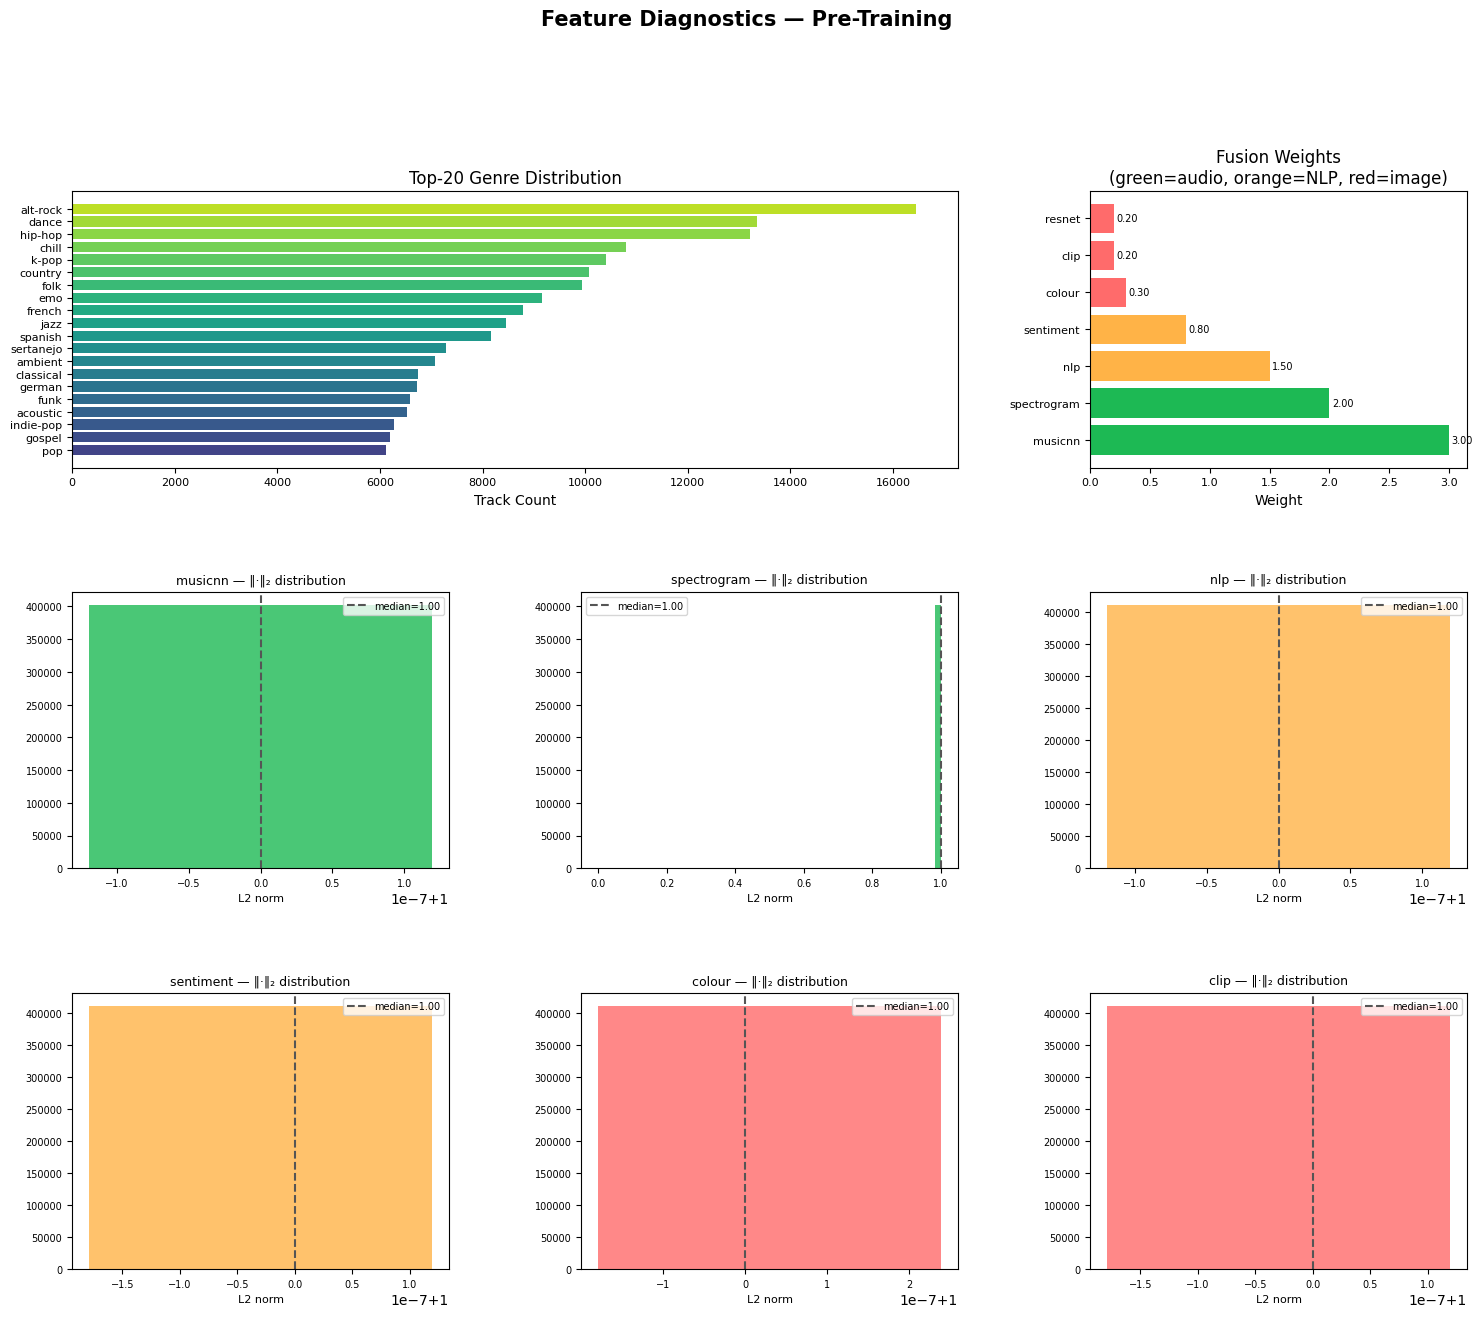


✅  EDA complete. Figure saved to eda_diagnostics.png

📊  Coverage heatmap:


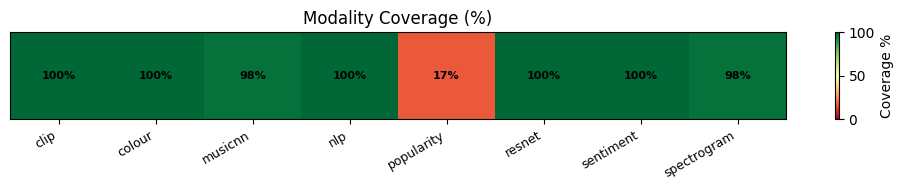

In [4]:
if not WEIGHTS_EXIST:
    # ── 4. EDA & Feature Diagnostics ─────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 14))
    fig.suptitle("Feature Diagnostics — Pre-Training", fontsize=15, fontweight='bold', y=1.01)
    gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
    
    # (a) Genre distribution
    ax1 = fig.add_subplot(gs[0, :2])
    genre_counts = metadata_df['genre'].value_counts().sort('count', descending=True).head(20)
    ax1.barh(genre_counts['genre'].to_list()[::-1], genre_counts['count'].to_list()[::-1],
             color=cm.viridis(np.linspace(0.2, 0.9, 20)))
    ax1.set_title("Top-20 Genre Distribution"); ax1.set_xlabel("Track Count")
    ax1.tick_params(labelsize=8)
    
    # (b) Modality weight comparison
    ax2 = fig.add_subplot(gs[0, 2])
    avail = {k: v for k, v in MODALITY_WEIGHTS.items() if k in feature_store}
    names = list(avail.keys()); vals = list(avail.values())
    colours = ['#1DB954' if k in ('musicnn','spectrogram') else
               '#FFB347' if k in ('nlp','sentiment') else '#FF6B6B'
               for k in names]
    bars = ax2.barh(names, vals, color=colours)
    ax2.set_title("Fusion Weights\n(green=audio, orange=NLP, red=image)")
    ax2.set_xlabel("Weight"); ax2.tick_params(labelsize=8)
    for bar, val in zip(bars, vals):
        ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=7)
    
    # (c-e) L2-norm distributions for each modality (top 3 by weight)
    top_mods = sorted(avail.keys(), key=lambda k: -avail[k])[:6]
    for i, name in enumerate(top_mods):
        ax = fig.add_subplot(gs[1 + i // 3, i % 3])
        norms = np.linalg.norm(feature_store[name], axis=1)
        data = norms[norms > 0]
        if len(data) > 0:
            diff = data.max() - data.min()
            b = 60 if diff > 1e-4 else 1
            ax.hist(data, bins=b, color='#1DB954' if name in ('musicnn','spectrogram')
                    else '#FFB347' if name in ('nlp','sentiment') else '#FF6B6B', alpha=0.8, edgecolor='none')
            ax.axvline(np.median(data), color='#555555', lw=1.5, ls='--', label=f'median={np.median(data):.2f}')
        ax.set_title(f"{name} — ‖·‖₂ distribution", fontsize=9)
        ax.set_xlabel("L2 norm", fontsize=8); ax.tick_params(labelsize=7)
        ax.legend(fontsize=7)
    
    plt.tight_layout()
    plt.savefig('eda_diagnostics.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("\n✅  EDA complete. Figure saved to eda_diagnostics.png")
    
    # Coverage bar
    print("\n📊  Coverage heatmap:")
    fig2, ax = plt.subplots(figsize=(10, 2))
    cov_vals = np.array([[coverage_report.get(k, 0) for k in sorted(feature_store.keys())]])
    im = ax.imshow(cov_vals, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(len(feature_store)))
    ax.set_xticklabels(sorted(feature_store.keys()), rotation=30, ha='right', fontsize=9)
    ax.set_yticks([]); ax.set_title("Modality Coverage (%)")
    plt.colorbar(im, ax=ax, label='Coverage %')
    for j, k in enumerate(sorted(feature_store.keys())):
        ax.text(j, 0, f"{coverage_report.get(k,0):.0f}%", ha='center', va='center', fontsize=8, color='black', fontweight='bold')
    plt.tight_layout()
    plt.show()
    

---
## 5. Model Architecture

**Audio-primary** asymmetric multimodal network.  
- Audio branch is **deepest and widest** — primary signal.  
- NLP/word branch is medium depth — secondary signal.  
- Image branch is **shallowest and narrowest** — auxiliary, low weight.  
- Fusion head combines the three projected embeddings with a gated attention.


In [5]:
# ── 5. Model Definition ───────────────────────────────────────────────────────
def _activation(name):
    return {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'leaky_relu': nn.LeakyReLU(0.1)}[name]

def _build_branch(in_dim, hidden_dim, out_dim, num_layers, dropout,
                  use_bn=True, use_residual=True, act='gelu'):
    """Build a generic MLP branch with optional BatchNorm and residual skip."""
    layers = []
    d_in = in_dim
    for i in range(num_layers - 1):
        d_out = hidden_dim
        layers += [nn.Linear(d_in, d_out)]
        if use_bn: layers.append(nn.BatchNorm1d(d_out))
        layers.append(_activation(act))
        layers.append(nn.Dropout(dropout))
        d_in = d_out
    layers.append(nn.Linear(d_in, out_dim))
    seq = nn.Sequential(*layers)

    class BranchModule(nn.Module):
        def __init__(self, seq, in_d, out_d, residual):
            super().__init__()
            self.seq = seq
            self.residual = residual and (in_d == out_d)
            self.proj = nn.Linear(in_d, out_d) if (residual and in_d != out_d) else None
        def forward(self, x):
            out = self.seq(x)
            if self.residual:
                skip = self.proj(x) if self.proj else x
                out = out + skip
            return out

    return BranchModule(seq, in_dim, out_dim, use_residual)


class MultimodalNet(nn.Module):
    """Audio-primary asymmetric multimodal network.

    Forward signature: forward(audio, nlp, img) → logits
    All branches are independently normalised before gated fusion.
    """
    def __init__(self, audio_dim, nlp_dim, img_dim, num_classes, params):
        super().__init__()
        P = params
        act  = P['activation']
        use_bn  = P['use_batch_norm']
        use_res = P['use_residual']

        # ── Branches ──────────────────────────────────────────────────────────
        self.audio_branch = _build_branch(
            audio_dim, P['audio_hidden_dim'], P['audio_output_dim'],
            P['audio_num_layers'], P['audio_dropout'], use_bn, use_res, act)

        self.nlp_branch = _build_branch(
            nlp_dim, P['nlp_hidden_dim'], P['nlp_output_dim'],
            P['nlp_num_layers'], P['nlp_dropout'], use_bn, use_res, act)

        self.img_branch = _build_branch(
            img_dim, P['img_hidden_dim'], P['img_output_dim'],
            P['img_num_layers'], P['img_dropout'], use_bn, use_res, act)

        fusion_in = P['audio_output_dim'] + P['nlp_output_dim'] + P['img_output_dim']

        # ── Gated attention over branches ─────────────────────────────────────
        self.gate = nn.Sequential(
            nn.Linear(fusion_in, 3),
            nn.Softmax(dim=-1)
        )
        # Learned weights broadcast over output dims
        self.audio_out_dim = P['audio_output_dim']
        self.nlp_out_dim   = P['nlp_output_dim']
        self.img_out_dim   = P['img_output_dim']

        # ── Fusion classifier ─────────────────────────────────────────────────
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, P['fusion_hidden_dim']),
            nn.BatchNorm1d(P['fusion_hidden_dim']) if use_bn else nn.Identity(),
            _activation(act),
            nn.Dropout(P['fusion_dropout']),
            nn.Linear(P['fusion_hidden_dim'], num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, audio, nlp, img, return_embeddings=False):
        a = self.audio_branch(audio)
        n = self.nlp_branch(nlp)
        v = self.img_branch(img)
        concat = torch.cat([a, n, v], dim=1)

        # Compute soft gates
        g = self.gate(concat)  # (B, 3) — audio, nlp, img gates
        a_w = g[:, 0:1] * a
        n_w = g[:, 1:2] * n
        v_w = g[:, 2:3] * v
        fused = torch.cat([a_w, n_w, v_w], dim=1)

        logits = self.fusion(fused)
        if return_embeddings:
            return logits, fused, g
        return logits


# ── Compute modality input dims ───────────────────────────────────────────────
def _dim(key, fallback=1):
    return feature_store[key].shape[1] if key in feature_store else fallback

# Audio: concatenate musicnn + spectrogram
audio_keys = [k for k in ('musicnn', 'spectrogram') if k in feature_store]
nlp_keys   = ['nlp']  # Aligned with v3 checkpoint (781-d)
img_keys   = ['colour']  # Aligned with v3 checkpoint (48-d)

def _cat_features(keys, store):
    if not keys: return np.zeros((N, 1), dtype=np.float32)
    return np.concatenate([store[k] for k in keys], axis=1)

audio_feats_combined = _cat_features(audio_keys, feature_store)
nlp_feats_combined   = _cat_features(nlp_keys,   feature_store)
img_feats_combined   = _cat_features(img_keys,    feature_store)

AUDIO_DIM = audio_feats_combined.shape[1]
NLP_DIM   = nlp_feats_combined.shape[1]
IMG_DIM   = img_feats_combined.shape[1]

print(f"Input dimensions:")
print(f"  Audio ({'+'.join(audio_keys)})  : {AUDIO_DIM}-d")
print(f"  NLP   ({'+'.join(nlp_keys)})    : {NLP_DIM}-d")
print(f"  Image ({'+'.join(img_keys)})    : {IMG_DIM}-d")

# ── Count parameters ──────────────────────────────────────────────────────────
top_genres_list = (metadata_df['genre'].value_counts()
                   .sort('count', descending=True)
                   .head(TRAIN_PARAMS['top_k_genres'])['genre'].to_list())
NUM_CLASSES = len(top_genres_list)

model = MultimodalNet(AUDIO_DIM, NLP_DIM, IMG_DIM, NUM_CLASSES, MODEL_PARAMS)
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  Total parameters  : {total_params:,}")
print(f"  Trainable params  : {train_params:,}")
print(f"  Number of classes : {NUM_CLASSES}  {top_genres_list}")


Input dimensions:
  Audio (musicnn+spectrogram)  : 458-d
  NLP   (nlp)    : 768-d
  Image (colour)    : 48-d

  Total parameters  : 1,215,826
  Trainable params  : 1,215,826
  Number of classes : 15  ['alt-rock', 'dance', 'hip-hop', 'chill', 'k-pop', 'country', 'folk', 'emo', 'french', 'jazz', 'spanish', 'sertanejo', 'ambient', 'classical', 'german']


---
## 6. Training


In [6]:
if WEIGHTS_EXIST:
    print(f"⚡  Skipping training — loading weights from {PATHS['model_ckpt']}")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = MultimodalNet(AUDIO_DIM, NLP_DIM, IMG_DIM, NUM_CLASSES, MODEL_PARAMS).to(device)
    model.load_state_dict(torch.load(PATHS['model_ckpt'], map_location=device, weights_only=True))
    model.eval()
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
               'lr':[], 'gate_audio':[], 'gate_nlp':[], 'gate_img':[]}
    print(f"✅  Weights loaded from {PATHS['model_ckpt']}")
else:
    # ── 6. Training Loop ──────────────────────────────────────────────────────────
    # Prepare tensors for filtered genres
    mask_series  = metadata_df['genre'].is_in(top_genres_list)
    mask_arr     = mask_series.to_numpy().astype(bool)
    filtered_meta = metadata_df.filter(mask_series)
    
    le = LabelEncoder()
    labels = le.fit_transform(filtered_meta['genre'].to_list())
    
    X_audio = torch.from_numpy(audio_feats_combined[mask_arr])
    X_nlp   = torch.from_numpy(nlp_feats_combined[mask_arr])
    X_img   = torch.from_numpy(img_feats_combined[mask_arr])
    y       = torch.tensor(labels, dtype=torch.long)
    
    rng = np.random.RandomState(TRAIN_PARAMS['random_seed'])
    idx_all = np.arange(len(y))
    train_idx, val_idx = train_test_split(
        idx_all, test_size=TRAIN_PARAMS['test_size'],
        random_state=TRAIN_PARAMS['random_seed'], stratify=labels)
    
    train_ds = TensorDataset(X_audio[train_idx], X_nlp[train_idx], X_img[train_idx], y[train_idx])
    val_ds   = TensorDataset(X_audio[val_idx],   X_nlp[val_idx],   X_img[val_idx],   y[val_idx])
    
    train_loader = DataLoader(train_ds, batch_size=TRAIN_PARAMS['batch_size'], shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=TRAIN_PARAMS['batch_size'], shuffle=False, num_workers=0)
    
    print(f"Train: {len(train_ds):,} samples   Val: {len(val_ds):,} samples")
    
    # Instantiate fresh model (or reload)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model  = MultimodalNet(AUDIO_DIM, NLP_DIM, IMG_DIM, NUM_CLASSES, MODEL_PARAMS).to(device)
    
    if os.path.exists(PATHS['model_ckpt']):
        print(f"Loading checkpoint from {PATHS['model_ckpt']}...")
        model.load_state_dict(torch.load(PATHS['model_ckpt'], map_location=device, weights_only=True))
    
    optimizer = optim.AdamW(model.parameters(),
                            lr=TRAIN_PARAMS['learning_rate'],
                            weight_decay=TRAIN_PARAMS['weight_decay'])
    criterion = nn.CrossEntropyLoss(label_smoothing=TRAIN_PARAMS['label_smoothing'])
    
    if TRAIN_PARAMS['lr_scheduler'] == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=TRAIN_PARAMS['epochs'], eta_min=1e-6)
    elif TRAIN_PARAMS['lr_scheduler'] == 'step':
        scheduler = optim.lr_scheduler.StepLR(
            optimizer, step_size=TRAIN_PARAMS['lr_step_size'], gamma=TRAIN_PARAMS['lr_gamma'])
    else:
        scheduler = None
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc':  [], 'val_acc':  [],
        'lr':         [],
        'gate_audio': [], 'gate_nlp': [], 'gate_img': [],
    }
    
    def accuracy(logits, targets):
        return (logits.argmax(dim=1) == targets).float().mean().item()
    
    for epoch in range(TRAIN_PARAMS['epochs']):
        # ── Train ────────────────────────────────────────────────────────────────
        model.train()
        t_loss = t_acc = 0
        for a, n, v, yb in tqdm(train_loader, desc=f"Epoch {epoch+1:2d}/{TRAIN_PARAMS['epochs']}", leave=False):
            a, n, v, yb = a.to(device), n.to(device), v.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(a, n, v)
            loss = criterion(out, yb)
            loss.backward()
            if TRAIN_PARAMS['grad_clip_norm'] > 0:
                nn.utils.clip_grad_norm_(model.parameters(), TRAIN_PARAMS['grad_clip_norm'])
            optimizer.step()
            t_loss += loss.item(); t_acc += accuracy(out, yb)
        if scheduler: scheduler.step()
    
        # ── Validate ──────────────────────────────────────────────────────────────
        model.eval()
        v_loss = v_acc = 0
        gate_vals = []
        with torch.no_grad():
            for a, n, v, yb in val_loader:
                a, n, v, yb = a.to(device), n.to(device), v.to(device), yb.to(device)
                logits, _, gates = model(a, n, v, return_embeddings=True)
                v_loss += criterion(logits, yb).item()
                v_acc  += accuracy(logits, yb)
                gate_vals.append(gates.mean(dim=0).cpu().numpy())
    
        mean_gates = np.mean(gate_vals, axis=0)
        history['train_loss'].append(t_loss / len(train_loader))
        history['val_loss'].append(v_loss / len(val_loader))
        history['train_acc'].append(t_acc  / len(train_loader))
        history['val_acc'].append(v_acc   / len(val_loader))
        history['lr'].append(optimizer.param_groups[0]['lr'])
        history['gate_audio'].append(mean_gates[0])
        history['gate_nlp'].append(mean_gates[1])
        history['gate_img'].append(mean_gates[2])
    
        print(f"  Ep {epoch+1:2d} | "
              f"Loss {history['train_loss'][-1]:.4f}/{history['val_loss'][-1]:.4f} | "
              f"Acc {history['train_acc'][-1]*100:.1f}%/{history['val_acc'][-1]*100:.1f}% | "
              f"LR {history['lr'][-1]:.2e} | "
              f"Gates A={mean_gates[0]:.3f} N={mean_gates[1]:.3f} I={mean_gates[2]:.3f}")
    
    torch.save(model.state_dict(), PATHS['model_ckpt'])
    print(f"\n✅  Model saved to {PATHS['model_ckpt']}")
    

Train: 124,654 samples   Val: 21,998 samples


Epoch  1/10:   0%|          | 0/974 [00:00<?, ?it/s]

  Ep  1 | Loss 1.5480/1.2644 | Acc 56.2%/65.2% | LR 2.93e-04 | Gates A=0.351 N=0.639 I=0.011


Epoch  2/10:   0%|          | 0/974 [00:00<?, ?it/s]

  Ep  2 | Loss 1.2896/1.1922 | Acc 64.6%/67.5% | LR 2.71e-04 | Gates A=0.356 N=0.639 I=0.005


...

  Ep  8 | Loss 1.0712/1.0982 | Acc 72.3%/71.2% | LR 2.96e-05 | Gates A=0.323 N=0.663 I=0.014


Epoch  9/10:   0%|          | 0/974 [00:00<?, ?it/s]

  Ep  9 | Loss 1.0561/1.0966 | Acc 72.8%/71.3% | LR 8.32e-06 | Gates A=0.317 N=0.662 I=0.021


Epoch 10/10:   0%|          | 0/974 [00:00<?, ?it/s]

  Ep 10 | Loss 1.0518/1.0957 | Acc 72.9%/71.2% | LR 1.00e-06 | Gates A=0.320 N=0.661 I=0.019

✅  Model saved to multimodal_v9f.pth


---
## 7. Training Diagnostics


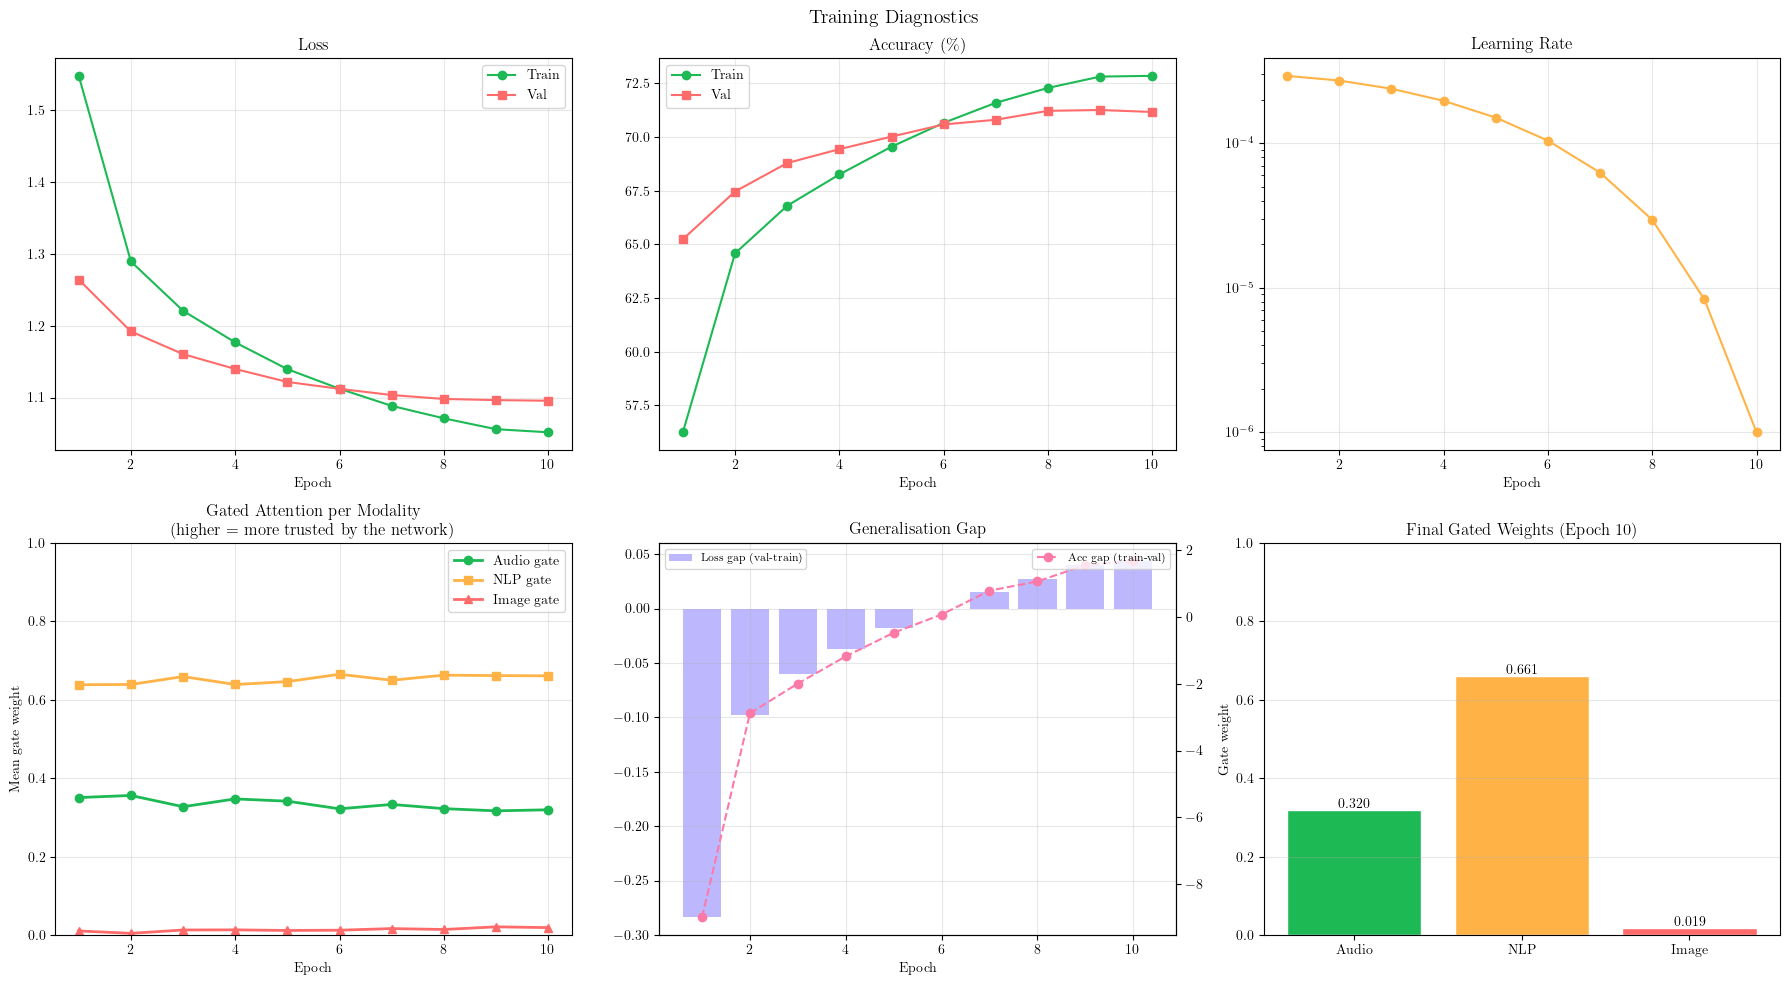


✅  Training diagnostics saved to training_diagnostics.png


In [7]:
if not WEIGHTS_EXIST:
    # ── 7. Training Visualisations ───────────────────────────────────────────────
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"],
        "text.latex.preamble": r"\usepackage{amsmath}" # Optional: add LaTeX packages
    })
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Training Diagnostics", fontsize=14, fontweight='bold')
    
    # (a) Loss curves
    ax = axes[0, 0]
    ax.plot(epochs_range, history['train_loss'], 'o-', label='Train', color='#1DB954')
    ax.plot(epochs_range, history['val_loss'],   's-', label='Val',   color='#FF6B6B')
    ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
    
    # (b) Accuracy curves
    ax = axes[0, 1]
    ax.plot(epochs_range, [x*100 for x in history['train_acc']], 'o-', label='Train', color='#1DB954')
    ax.plot(epochs_range, [x*100 for x in history['val_acc']],   's-', label='Val',   color='#FF6B6B')
    ax.set_title("Accuracy (\%)"); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
    
    # (c) Learning rate schedule
    ax = axes[0, 2]
    ax.plot(epochs_range, history['lr'], 'o-', color='#FFB347')
    ax.set_title("Learning Rate"); ax.set_xlabel("Epoch")
    ax.set_yscale('log'); ax.grid(alpha=0.3)
    
    # (d) Gate evolution — shows how much each modality the network learned to trust
    ax = axes[1, 0]
    ax.plot(epochs_range, history['gate_audio'], 'o-', label='Audio gate',  color='#1DB954', lw=2)
    ax.plot(epochs_range, history['gate_nlp'],   's-', label='NLP gate',    color='#FFB347', lw=2)
    ax.plot(epochs_range, history['gate_img'],   '^-', label='Image gate',  color='#FF6B6B', lw=2)
    ax.set_title("Gated Attention per Modality\n(higher = more trusted by the network)")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Mean gate weight"); ax.legend(); ax.grid(alpha=0.3)
    ax.set_ylim(0, 1)
    
    # (e) Train-val gap
    ax = axes[1, 1]
    gap_loss = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
    gap_acc  = [t - v for t, v in zip(history['train_acc'],  history['val_acc'])]
    ax.bar(epochs_range, gap_loss, alpha=0.7, color='#A29BFE', label='Loss gap (val-train)')
    ax2b = ax.twinx()
    ax2b.plot(epochs_range, [x*100 for x in gap_acc], 'o--', color='#FD79A8', label='Acc gap (train-val) %')
    ax.set_title("Generalisation Gap"); ax.set_xlabel("Epoch")
    ax.legend(loc='upper left', fontsize=8); ax2b.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)
    
    # (f) Final gate bar at last epoch
    ax = axes[1, 2]
    final_gates = [history['gate_audio'][-1], history['gate_nlp'][-1], history['gate_img'][-1]]
    bar_colours = ['#1DB954', '#FFB347', '#FF6B6B']
    bars = ax.bar(['Audio', 'NLP', 'Image'], final_gates, color=bar_colours, edgecolor='white')
    for bar, val in zip(bars, final_gates):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}',
                ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f"Final Gated Weights (Epoch {len(epochs_range)})")
    ax.set_ylabel("Gate weight"); ax.set_ylim(0, 1); ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_diagnostics.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("\n✅  Training diagnostics saved to training_diagnostics.png")
    

---
## 8. Recommendation Engine

Computes weighted cosine similarity across all loaded modalities with configurable weights.
Includes Maximum Marginal Relevance (MMR) for diversity control and per-modality breakdowns.


In [8]:
# -- 8. Weighted Recommendation Engine (v9) -----------------------------------

def _cosine_sim_batch(query_vec, matrix):
    """Vectorised cosine similarity: query_vec (1,D), matrix (N,D) -> (N,)."""
    q = query_vec / (np.linalg.norm(query_vec) + 1e-9)
    m = matrix    / (np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-9)
    return (m @ q.T).ravel()

def _dot_sim_batch(query_vec, matrix):
    return (matrix @ query_vec.T).ravel()

def _euclidean_sim_batch(query_vec, matrix):
    dists = np.linalg.norm(matrix - query_vec, axis=1)
    return 1.0 / (1.0 + dists)

def _manhattan_sim_batch(query_vec, matrix):
    dists = np.sum(np.abs(matrix - query_vec), axis=1)
    return 1.0 / (1.0 + dists)

def _mmr(query_sims, sim_matrix, alpha, k):
    """Maximum Marginal Relevance: alpha=0 pure similarity, alpha=1 max diversity."""
    selected, remaining = [], list(range(len(query_sims)))
    for _ in range(k):
        if not remaining: break
        if not selected:
            best = max(remaining, key=lambda i: query_sims[i])
        else:
            best = max(
                remaining,
                key=lambda i: (1 - alpha) * query_sims[i]
                              - alpha * max(sim_matrix[i, s] for s in selected)
            )
        selected.append(best); remaining.remove(best)
    return selected


def _metadata_sim(picked_idx, meta_weights):
    """Compute per-track metadata similarity score against the seed track."""
    meta_sim = np.zeros(N, dtype=np.float64)
    total_w  = 0.0
    row_seed = metadata_df.row(int(picked_idx), named=True)

    # Genre similarity (exact match bonus)
    w_genre = meta_weights.get('genre_sim', 0.0)
    if w_genre != 0:
        seed_genre = row_seed.get('genre', '')
        genres     = metadata_df['genre'].to_list()
        genre_match = np.array([1.0 if g == seed_genre else 0.0 for g in genres], dtype=np.float64)
        meta_sim += genre_match * w_genre
        total_w  += abs(w_genre)

    # Scalar audio feature proximity
    scalar_feats   = ['danceability', 'energy', 'valence', 'tempo', 'acousticness']
    for feat in scalar_feats:
        w_f = meta_weights.get(feat, 0.0)
        if w_f == 0 or feat not in metadata_df.columns: continue
        seed_val = row_seed.get(feat)
        if seed_val is None: continue
        vals = metadata_df[feat].fill_null(seed_val).to_numpy().astype(np.float64)
        max_range = vals.max() - vals.min() + 1e-9
        proximity = 1.0 - np.abs(vals - seed_val) / max_range
        meta_sim += proximity * w_f
        total_w  += abs(w_f)

    # Popularity
    w_pop = meta_weights.get('popularity', 0.0)
    if w_pop != 0 and 'popularity' in metadata_df.columns:
        pop_vals = metadata_df['popularity'].fill_null(0).to_numpy().astype(np.float64)
        pop_norm = pop_vals / (pop_vals.max() + 1e-9)
        meta_sim += pop_norm * w_pop
        total_w  += abs(w_pop)

    # Language similarity (match on language column if available, else neutral)
    w_lang = meta_weights.get('language_sim', 0.0)
    if w_lang != 0:
        lang_col = 'language' if 'language' in metadata_df.columns else None
        if lang_col:
            seed_lang = row_seed.get(lang_col, '')
            langs = metadata_df[lang_col].fill_null('').to_list()
            lang_match = np.array([1.0 if l == seed_lang and seed_lang else 0.5 for l in langs])
        else:
            lang_match = np.full(N, 0.5, dtype=np.float64)
        meta_sim += lang_match * w_lang
        total_w  += abs(w_lang)

    if total_w > 0:
        meta_sim /= total_w
    return meta_sim


def get_recommendations(picked_idx, top_n=None, weights_override=None,
                        meta_weights_override=None, sim_metric=None,
                        temperature=None, diversity_alpha=None,
                        min_score=None, serendipity=None):
    """
    Return (indices, scores, per_modality_scores_dict) for a given seed track.

    serendipity in [0,1]: fraction of results injected from LOW-similarity
    (distant neighbours) to surface unexpected hidden gems.
    """
    top_n     = top_n or SEARCH_PARAMS['max_recs']
    w_over    = weights_override or {}
    mw        = meta_weights_override if meta_weights_override is not None else METADATA_WEIGHTS.copy()
    metric    = sim_metric    or SEARCH_PARAMS['similarity_metric']
    temp      = temperature   if temperature   is not None else SEARCH_PARAMS['temperature']
    alpha     = diversity_alpha if diversity_alpha is not None else SEARCH_PARAMS['diversity_alpha']
    min_sc    = min_score     if min_score      is not None else SEARCH_PARAMS['min_score_threshold']
    seren     = serendipity   if serendipity    is not None else SEARCH_PARAMS['serendipity']

    combined_sim = np.zeros(N, dtype=np.float64)
    total_weight = 0.0
    per_mod_sims = {}

    sim_fn = {
        'cosine'   : _cosine_sim_batch,
        'dot'      : _dot_sim_batch,
        'euclidean': _euclidean_sim_batch,
        'manhattan': _manhattan_sim_batch,
    }.get(metric, _cosine_sim_batch)

    for name, feats in feature_store.items():
        w = w_over.get(name, MODALITY_WEIGHTS.get(name, 0.0))
        if w == 0: continue
        query_vec = feats[picked_idx : picked_idx + 1]
        if np.linalg.norm(query_vec) < 1e-9: continue
        sims = sim_fn(query_vec, feats).astype(np.float64)
        sims = np.nan_to_num(sims, nan=0.0)
        per_mod_sims[name] = sims
        combined_sim += sims * w
        total_weight  += abs(w)

    # Metadata component
    meta_total_w = sum(abs(v) for v in mw.values())
    if meta_total_w > 0:
        meta_sim = _metadata_sim(picked_idx, mw)
        per_mod_sims['metadata'] = meta_sim
        combined_sim += meta_sim * meta_total_w
        total_weight  += meta_total_w

    if total_weight > 0:
        combined_sim /= total_weight

    # Temperature sharpening
    if temp != 1.0 and temp > 0:
        combined_sim = combined_sim ** (1.0 / temp)

    # Exclude self and below-threshold
    candidate_mask = np.ones(N, dtype=bool)
    candidate_mask[picked_idx] = False
    candidate_mask &= combined_sim >= min_sc
    candidate_indices = np.where(candidate_mask)[0]

    # ------------------------------------------------------------------
    # Serendipity injection: mix top-similarity with distant neighbours
    # ------------------------------------------------------------------
    if seren > 0 and len(candidate_indices) > 0:
        n_seren  = max(1, int(top_n * seren))
        n_normal = top_n - n_seren
        cand_sims = combined_sim[candidate_indices]
        order_desc = np.argsort(cand_sims)[::-1]
        normal_pool = candidate_indices[order_desc[:max(n_normal, 1)]]
        # Bottom of similarity space -> sample for freshness
        order_asc        = np.argsort(cand_sims)
        seren_pool_size  = min(len(candidate_indices) // 2, max(n_seren * 5, 50))
        seren_pool_idx   = candidate_indices[order_asc[:seren_pool_size]]
        if len(seren_pool_idx) > n_seren:
            seren_chosen = np.random.choice(seren_pool_idx, size=n_seren, replace=False)
        else:
            seren_chosen = seren_pool_idx
        top_indices = np.unique(np.concatenate([normal_pool[:n_normal], seren_chosen]))[:top_n]
        scores      = combined_sim[top_indices]
        sort_order  = np.argsort(scores)[::-1]
        top_indices = top_indices[sort_order]
        scores      = scores[sort_order]

    elif alpha > 0 and len(candidate_indices) > 0:
        cand_sims = combined_sim[candidate_indices]
        audio_key = 'musicnn' if 'musicnn' in feature_store else list(feature_store.keys())[0]
        audio_c   = feature_store[audio_key][candidate_indices]
        a_norm    = audio_c / (np.linalg.norm(audio_c, axis=1, keepdims=True) + 1e-9)
        sim_matrix = a_norm @ a_norm.T
        selected_local = _mmr(cand_sims, sim_matrix, alpha, top_n)
        top_indices = candidate_indices[selected_local]
        scores      = combined_sim[top_indices]

    else:
        order       = np.argsort(combined_sim[candidate_indices])[::-1][:top_n]
        top_indices = candidate_indices[order]
        scores      = combined_sim[top_indices]

    return top_indices, scores, per_mod_sims

print("  Recommendation engine v9 ready.")
print(f"   Modalities used : {list(feature_store.keys())}")
print(f"   Metric          : {SEARCH_PARAMS['similarity_metric']}")
print(f"   Serendipity     : {SEARCH_PARAMS['serendipity']}")


  Recommendation engine v9 ready.
   Modalities used : ['musicnn', 'spectrogram', 'nlp', 'sentiment', 'resnet', 'clip', 'popularity', 'colour']
   Metric          : cosine
   Serendipity     : 0.0


---
## 9. Interactive Search & Recommendation UI

- **Search** by song/artist name  
- **Page** through results (next/prev buttons)  
- **Tune** modality weights and search parameters live  
- **Similarity breakdown** chart per recommendation  


In [9]:
# import plotly.io as pio
# import plotly.graph_objects as go

# # 1. Create a custom template based on the clean 'plotly_white'
# latex_style = go.layout.Template()

# # 2. Set the universal font (STIX is the web-standard for LaTeX-like serifs)
# latex_style.layout.font = dict(
#     family="STIX Two Text, Times New Roman, serif", 
#     size=14, 
#     color="black"
# )

# # 3. Optimize axes for a "Scientific Paper" look
# latex_style.layout.xaxis = dict(ticks="outside", showline=True, mirror=True, linecolor="black")
# latex_style.layout.yaxis = dict(ticks="outside", showline=True, mirror=True, linecolor="black")

# # 4. Register and set as the global default
# # We combine 'plotly_white' with our custom 'latex_style'
# pio.templates["latex_paper"] = latex_style
# pio.templates.default = "plotly_white+latex_paper"

In [ ]:
# -- Helper widgets (v9) -------------------------------------------------------
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

def _get_track_url(track_id, col):
    """Look up a URL column from metadata_df by track_id."""
    if col not in metadata_df.columns:
        return None
    idx = id_to_idx.get(str(track_id))
    if idx is None:
        return None
    val = metadata_df[col][idx]
    return val if (val and str(val).startswith('http')) else None

def get_audio_widget(track_id):
    url = _get_track_url(track_id, 'preview_url')
    if url:
        return widgets.HTML(f'<audio src="{url}" controls style="height:28px;width:240px;"></audio>')
    return widgets.HTML('<span style="color:#555;font-size:10px;">no preview</span>')

def _get_album_cover_url(track_id, target_size=300):
    """Extract the closest-to-target_size image URL from the 'album' struct column."""
    if 'album' not in metadata_df.columns:
        return None
    idx = id_to_idx.get(str(track_id))
    if idx is None:
        return None
    album = metadata_df['album'][idx]
    if album is None:
        return None
    try:
        images = album.get('images') if isinstance(album, dict) else None
        if images is None and hasattr(album, '__getitem__'):
            images = album['images']
        if not images:
            return None
        best = min(images, key=lambda img: abs((img.get('height') or 0) - target_size))
        return best.get('url')
    except Exception:
        return None

def get_cover_widget(track_id, size=50):
    url = _get_album_cover_url(track_id, target_size=300)
    if url:
        return widgets.HTML(
            f"""<img src="{url}" width="{size}" height="{size}" """
            f"""style="border-radius:4px;object-fit:cover;" """
            f"""onerror="this.style.display='none'">""")
    return widgets.HTML(
        f'<div style="width:{size}px;height:{size}px;background:#2d2d2d;'
        f'border-radius:4px;display:flex;align-items:center;justify-content:center;'
        f'color:#888;font-size:9px;">♪</div>'
    )


# ──────────────────────────────────────────────────────────────────────────────
# CHANGE 5: Help button factory
# ──────────────────────────────────────────────────────────────────────────────
_HELP_TEXTS = {
    'musicnn'   : 'MusicNN: Deep audio embedding (200-d) trained on music tags. Captures timbral texture, genre, and high-level sonic character. The primary signal — keep this high.',
    'spectrogram': 'Spectrogram: Raw mel-spectrogram features capturing frequency content over time. Complements MusicNN with low-level audio structure like rhythm and harmonics.',
    'nlp'       : 'NLP / Lyrics: Multilingual sentence embeddings of lyrics + genre text. Captures thematic similarity, poetic style, and semantic meaning across languages.',
    'sentiment' : 'Sentiment: Emotional tone matrix derived from lyric analysis. Captures mood dimensions like positivity, aggression, melancholy. Complements NLP.',
    'colour'    : 'Colour Palette: K-means colour features from album art. Low-level visual proxy for aesthetic/era. Keep weight low — art rarely encodes musical content.',
    'clip'      : 'CLIP Visual: OpenAI CLIP embeddings of album art. Richer visual semantics than raw colour. Useful for The Aesthete preset — art-driven recommendations.',
    'resnet'    : 'ResNet Image: Deep ResNet-50 image embeddings of album covers. Captures compositional and stylistic visual features. Auxiliary signal only.',
    'genre_sim' : 'Genre Similarity: Exact-match bonus for same genre. High values keep recs genre-locked; negative values push cross-genre discovery.',
    'popularity': 'Popularity: Boosts (positive) or penalises (negative) mainstream tracks. Set negative to surface obscure gems; set positive for chart-friendly picks.',
    'language_sim': 'Language Similarity: Rewards tracks in the same language as the seed. Set negative (Globetrotter) to surface international interpretations.',
    'danceability': 'Danceability: Spotify feature [0–1] measuring rhythmic suitability for dancing. High = prioritise similar groove/rhythm.',
    'energy'    : 'Energy: Spotify perceptual intensity [0–1] — loudness, tempo, activity. High = match energy level; useful for workout/party playlists.',
    'valence'   : 'Valence: Spotify positivity [0–1]. High = happy/euphoric; low = sad/angry. Matches emotional tone of the seed track.',
    'tempo'     : 'Tempo: BPM proximity. High weight matches energy and pace (useful for running playlists). Lower weight allows tempo variation.',
    'acousticness': 'Acousticness: Acoustic vs. electronic [0–1]. High = match acoustic warmth; negative = prefer electronic over acoustic.',
    'results_per_page': 'How many search results to show per page in the song search panel.',
    'recs_per_page'   : 'How many recommendations to display per page in the results list.',
    'max_recs'        : 'Total number of recommendations to compute. More = slower but richer pool for MMR/serendipity.',
    'temperature'     : 'Score temperature: <1 sharpens the distribution (top tracks dominate more); >1 flattens it (scores converge). Default 1.0 = no change.',
    'diversity_alpha' : 'MMR Diversity Alpha: 0 = pure similarity ranking. Higher values use Maximum Marginal Relevance to penalise redundant recommendations — increases genre/style variety.',
    'min_score'       : 'Minimum combined similarity score threshold. Tracks scoring below this value are excluded from results.',
    'serendipity'     : 'Serendipity: Injects tracks from the LOW-similarity end of the space. Breaks echo chambers — surfaces surprising, unexpected hidden gems.',
}

def _help_btn(key):
    """Return a blue ? button that shows a tooltip on click."""
    tip = _HELP_TEXTS.get(key, '')
    btn = widgets.Button(
        description='❓',
        tooltip=tip,
        layout=widgets.Layout(width='32px', height='28px', margin='0 0 0 4px'),
        style={'button_color': '#1565C0'},
    )
    help_out = widgets.Output()
    def _toggle(b, out=help_out, t=tip):
        with out:
            clear_output(wait=True)
            if out._last_toggle if hasattr(out, '_last_toggle') else True:
                display(widgets.HTML(
                    f'<div style="background:#1a2b4a;color:#90CAF9;font-size:11px;'
                    f'padding:6px 10px;border-radius:6px;max-width:400px;line-height:1.6;">'
                    f'{t}</div>'
                ))
                out._last_toggle = False
            else:
                out._last_toggle = True
    btn.on_click(_toggle)
    return btn, help_out

def _slider_row(slider, key):
    """Wrap a slider with a help button into an HBox."""
    btn, out = _help_btn(key)
    return widgets.VBox([
        widgets.HBox([slider, btn], layout=widgets.Layout(align_items='center')),
        out,
    ])

# ===========================================================================
# PRESETS  (modality weights + metadata weights + serendipity)
# ===========================================================================
PRESETS = {
    'Default': {
        'modality': {'musicnn':3.0,'spectrogram':2.0,'nlp':1.5,'sentiment':0.8,
                     'colour':0.3,'clip':0.2,'resnet':0.2},
        'metadata': {'genre_sim':0.5,'popularity':0.15,'language_sim':0.3,
                     'danceability':0.2,'energy':0.2,'valence':0.2,'tempo':0.1,'acousticness':0.1},
        'serendipity': 0.0,
    },
    '🧭 The Discover': {
        'modality': {'musicnn':3.0,'spectrogram':2.0,'nlp':1.5,'sentiment':0.8,
                     'colour':0.3,'clip':0.2,'resnet':0.2},
        'metadata': {'genre_sim':0.3,'popularity':-1.5,'language_sim':0.3,
                     'danceability':0.2,'energy':0.2,'valence':0.2,'tempo':0.1,'acousticness':0.1},
        'serendipity': 0.0,
    },
    '🎩 The Music Snob': {
        'modality': {'musicnn':5.0,'spectrogram':3.5,'nlp':2.0,'sentiment':1.5,
                     'colour':0.0,'clip':0.0,'resnet':0.0},
        'metadata': {'genre_sim':0.8,'popularity':0.0,'language_sim':0.0,
                     'danceability':0.0,'energy':0.0,'valence':0.0,'tempo':0.0,'acousticness':0.0},
        'serendipity': 0.0,
    },
    '🎨 The Aesthete': {
        'modality': {'musicnn':1.0,'spectrogram':0.5,'nlp':0.5,'sentiment':0.3,
                     'colour':2.0,'clip':3.0,'resnet':2.5},
        'metadata': {'genre_sim':0.1,'popularity':0.1,'language_sim':0.0,
                     'danceability':0.0,'energy':0.0,'valence':0.0,'tempo':0.0,'acousticness':0.0},
        'serendipity': 0.0,
    },
    '🐦‍⬛ The Maverick': {
        'modality': {'musicnn':2.0,'spectrogram':2.0,'nlp':0.5,'sentiment':0.3,
                     'colour':0.1,'clip':0.1,'resnet':0.1},
        'metadata': {'genre_sim':0.0,'popularity':-2.0,'language_sim':0.0,
                     'danceability':0.0,'energy':0.0,'valence':0.0,'tempo':0.0,'acousticness':0.0},
        'serendipity': 0.0,
    },
    '❤️‍🔥 The Devotee': {
        'modality': {'musicnn':3.0,'spectrogram':2.5,'nlp':3.5,'sentiment':2.0,
                     'colour':0.5,'clip':0.3,'resnet':0.3},
        'metadata': {'genre_sim':1.0,'popularity':0.5,'language_sim':0.8,
                     'danceability':0.3,'energy':0.3,'valence':0.3,'tempo':0.2,'acousticness':0.1},
        'serendipity': 0.0,
    },
    '📜 The Lyricist': {
        'modality': {'musicnn':0.5,'spectrogram':0.3,'nlp':5.0,'sentiment':3.5,
                     'colour':0.0,'clip':0.0,'resnet':0.0},
        'metadata': {'genre_sim':0.4,'popularity':0.0,'language_sim':1.5,
                     'danceability':0.0,'energy':0.0,'valence':0.4,'tempo':0.0,'acousticness':0.0},
        'serendipity': 0.0,
    },
    '🏃‍♂️ The Kinetic': {
        'modality': {'musicnn':5.0,'spectrogram':4.0,'nlp':0.0,'sentiment':0.0,
                     'colour':0.0,'clip':0.0,'resnet':0.0},
        'metadata': {'genre_sim':0.0,'popularity':0.0,'language_sim':0.0,
                     'danceability':2.0,'energy':2.5,'valence':0.0,'tempo':2.0,'acousticness':-1.0},
        'serendipity': 0.0,
    },
    '💾 The Archivist': {
        'modality': {'musicnn':2.5,'spectrogram':4.0,'nlp':0.5,'sentiment':0.3,
                     'colour':0.5,'clip':0.2,'resnet':0.2},
        'metadata': {'genre_sim':0.8,'popularity':-0.5,'language_sim':0.3,
                     'danceability':0.0,'energy':0.0,'valence':0.0,'tempo':0.3,'acousticness':1.5},
        'serendipity': 0.0,
    },
    '🌍 The Globetrotter': {
        'modality': {'musicnn':4.0,'spectrogram':2.0,'nlp':1.0,'sentiment':0.5,
                     'colour':0.3,'clip':0.2,'resnet':0.2},
        'metadata': {'genre_sim':0.5,'popularity':0.0,'language_sim':-2.5,
                     'danceability':0.3,'energy':0.3,'valence':0.3,'tempo':0.0,'acousticness':0.0},
        'serendipity': 0.1,
    },
    '🎼 The Wall of Sound': {
        'modality': {'musicnn':3.0,'spectrogram':5.0,'nlp':0.0,'sentiment':0.0,
                     'colour':1.5,'clip':1.5,'resnet':1.5},
        'metadata': {'genre_sim':0.5,'popularity':0.0,'language_sim':0.0,
                     'danceability':0.0,'energy':2.0,'valence':0.0,'tempo':0.0,'acousticness':-2.0},
        'serendipity': 0.0,
    },
}

PRESET_DESCRIPTIONS = {
    'Default'          : 'Balanced default -- Audio > NLP > Image.',
    '🧭 The Discover'     : 'Surface hidden gems: penalises popular tracks, keeps default audio/NLP balance.',
    '🎩 The Music Snob'   : 'Audio purist: maximises MusicNN + Spectrogram, solid NLP, zero image.',
    '🎨 The Aesthete'     : 'Visual vibes: CLIP, colour, ResNet dominate. Lower audio, minimal lyrics.',
    '🐦‍⬛ The Maverick'     : 'Structural outliers via deep audio latent space, strongly penalises popularity.',
    '❤️‍🔥 The Devotee'      : 'Same-artist affinity: high audio + NLP + genre + language matching.',
    '📜 The Lyricist'     : 'Semantic depth & storytelling: prioritises NLP lyric/thematic embeddings, '
                         'language match and emotional valence. Ignores album art entirely.',
    '🏃‍♂️ The Kinetic'      : 'Energy, tempo & movement: max BPM, energy and danceability. Ignores lyrics '
                         'and popularity. Built for high-intensity environments and the dance floor.',
    '💾 The Archivist'    : 'Chronology & vintage textures: spectral features emphasised for lo-fi/tape '
                         'qualities, acousticness boosted, popularity penalised, genre-locked.',
    '🌍 The Globetrotter' : 'Cultural variance & diversity: audio vibe preserved but language similarity '
                         'is penalised -- deliberately surfaces international interpretations.',
    '🎼 The Wall of Sound': 'Production density & maximalism: spectral density + energy + visual embeddings '
                         'maximised. Acousticness penalised. Lyric clarity irrelevant.',
}

# ===========================================================================
# WIDGET DEFINITIONS
# ===========================================================================
style       = {'description_width': '180px'}
layout_wide = widgets.Layout(width='420px')
layout_med  = widgets.Layout(width='350px')

# Modality sliders
w_musicnn    = widgets.FloatSlider(value=MODALITY_WEIGHTS.get('musicnn',3.0),    min=-5,max=5,step=0.1, description='Weight: musicnn (audio)',    style=style,layout=layout_wide,continuous_update=False)
w_specgram   = widgets.FloatSlider(value=MODALITY_WEIGHTS.get('spectrogram',2.0),min=-5,max=5,step=0.1, description='Weight: spectrogram (audio)',style=style,layout=layout_wide,continuous_update=False)
w_nlp        = widgets.FloatSlider(value=MODALITY_WEIGHTS.get('nlp',1.5),        min=-5,max=5,step=0.1, description='Weight: nlp (word)',          style=style,layout=layout_wide,continuous_update=False)
w_sentiment  = widgets.FloatSlider(value=MODALITY_WEIGHTS.get('sentiment',0.8),  min=-5,max=5,step=0.1, description='Weight: sentiment (word)',    style=style,layout=layout_wide,continuous_update=False)
w_colour     = widgets.FloatSlider(value=MODALITY_WEIGHTS.get('colour',0.3),     min=-5,max=5,step=0.05,description='Weight: colour (image)',      style=style,layout=layout_wide,continuous_update=False)
w_clip       = widgets.FloatSlider(value=MODALITY_WEIGHTS.get('clip',0.2),       min=-5,max=5,step=0.05,description='Weight: CLIP (image)',        style=style,layout=layout_wide,continuous_update=False)
w_resnet     = widgets.FloatSlider(value=MODALITY_WEIGHTS.get('resnet',0.2),     min=-5,max=5,step=0.05,description='Weight: ResNet (image)',      style=style,layout=layout_wide,continuous_update=False)

# Metadata sliders
w_meta_genre    = widgets.FloatSlider(value=METADATA_WEIGHTS['genre_sim'],    min=-5,max=5,step=0.05,description='Genre similarity',   style=style,layout=layout_wide,continuous_update=False)
w_meta_pop      = widgets.FloatSlider(value=METADATA_WEIGHTS['popularity'],   min=-5,max=5,step=0.05,description='Popularity',         style=style,layout=layout_wide,continuous_update=False)
w_meta_lang     = widgets.FloatSlider(value=METADATA_WEIGHTS['language_sim'], min=-5,max=5,step=0.05,description='Language similarity', style=style,layout=layout_wide,continuous_update=False)
w_meta_dance    = widgets.FloatSlider(value=METADATA_WEIGHTS['danceability'],  min=-5,max=5,step=0.05,description='Danceability',       style=style,layout=layout_wide,continuous_update=False)
w_meta_energy   = widgets.FloatSlider(value=METADATA_WEIGHTS['energy'],        min=-5,max=5,step=0.05,description='Energy',             style=style,layout=layout_wide,continuous_update=False)
w_meta_valence  = widgets.FloatSlider(value=METADATA_WEIGHTS['valence'],       min=-5,max=5,step=0.05,description='Valence',            style=style,layout=layout_wide,continuous_update=False)
w_meta_tempo    = widgets.FloatSlider(value=METADATA_WEIGHTS['tempo'],         min=-5,max=5,step=0.05,description='Tempo',              style=style,layout=layout_wide,continuous_update=False)
w_meta_acoustic = widgets.FloatSlider(value=METADATA_WEIGHTS['acousticness'],  min=-5,max=5,step=0.05,description='Acousticness',       style=style,layout=layout_wide,continuous_update=False)

# Search/retrieval sliders
s_results_per_page = widgets.IntSlider(value=SEARCH_PARAMS['results_per_page'],  min=5, max=50, step=5,    description='Search results / page',style=style,layout=layout_wide,continuous_update=False)
s_recs_per_page    = widgets.IntSlider(value=SEARCH_PARAMS['recs_per_page'],     min=5, max=50, step=5,    description='Recs / page',          style=style,layout=layout_wide,continuous_update=False)
s_max_recs         = widgets.IntSlider(value=SEARCH_PARAMS['max_recs'],          min=10,max=300,step=10,   description='Max recommendations',  style=style,layout=layout_wide,continuous_update=False)
s_temperature      = widgets.FloatSlider(value=SEARCH_PARAMS['temperature'],     min=0.1,max=3.0,step=0.05,description='Score temperature',    style=style,layout=layout_wide,continuous_update=False)
s_diversity        = widgets.FloatSlider(value=SEARCH_PARAMS['diversity_alpha'], min=0,  max=1,  step=0.05,description='MMR diversity alpha',  style=style,layout=layout_wide,continuous_update=False)
s_serendipity      = widgets.FloatSlider(value=SEARCH_PARAMS['serendipity'],     min=0,  max=1,  step=0.05,description='Serendipity',          style=style,layout=layout_wide,continuous_update=False)
s_min_score        = widgets.FloatSlider(value=SEARCH_PARAMS['min_score_threshold'],min=0,max=0.99,step=0.01,description='Min similarity score',style=style,layout=layout_wide,continuous_update=False)
s_metric           = widgets.Dropdown(options=['cosine','dot','euclidean','manhattan'],value=SEARCH_PARAMS['similarity_metric'],description='Similarity metric',style=style,layout=layout_med)
s_show_breakdown   = widgets.Checkbox(value=True,description='Show per-modality breakdown chart',style=style)


SIMILARITY_METRIC_DESCRIPTIONS = {
    'cosine'   : '📐 <b>Cosine</b>: Measures the angle between two feature vectors in embedding space — direction only, not magnitude. Best for dense embeddings (MusicNN, NLP). The standard choice for most use cases.',
    'dot'      : '⚡ <b>Dot Product</b>: Raw inner product — rewards both alignment <em>and</em> magnitude. Higher-energy tracks can dominate; useful when you want popularity/loudness to implicitly influence results.',
    'euclidean': '📏 <b>Euclidean</b>: Straight-line distance in feature space, converted to similarity via 1/(1+d). More sensitive to absolute feature values; can penalise spectral outliers.',
    'manhattan': '🏙️ <b>Manhattan</b>: Sum of absolute differences per dimension (L1 norm), converted to similarity via 1/(1+d). More robust to single-feature outliers than Euclidean; slower on high-d embeddings.',
}

# def _render_metric_desc(metric):
#     desc = SIMILARITY_METRIC_DESCRIPTIONS.get(metric, '')
#     return (
#         f'<div style="color:#aaa;font-size:11px;margin:2px 0 8px 0;line-height:1.6;"'>
#         f'{desc}</div>'
#     )

def _render_metric_desc(metric):
    desc = SIMILARITY_METRIC_DESCRIPTIONS.get(metric, '')
    
    # Ensure we return an empty string if desc is None or False
    if not desc:
        return "" 
        
    return (
        f'<div style="color:#aaa;font-size:11px;margin:2px 0 8px 0;line-height:1.6;">'
        f'{desc}</div>'
    )

metric_desc_html = widgets.HTML(_render_metric_desc(SEARCH_PARAMS['similarity_metric']))

def _on_metric_change(change):
    metric_desc_html.value = _render_metric_desc(change['new'])

serendipity_help = widgets.HTML(
    '<div style="color:#aaa;font-size:11px;margin:2px 0 8px 0;line-height:1.5;">'
    '<b>Serendipity Slider</b>: Injects "distant" neighbours from the vector space. '
    'When high, the algorithm retrieves songs with <em>low</em> cosine similarity instead of high, '
    'occasionally surfacing hidden gems -- breaking the echo-chamber of nearest neighbours.'
    '</div>'
)

# Apply buttons
_apply_btns = [
    widgets.Button(description='Apply Parameters', button_style='success', icon='check',
                   layout=widgets.Layout(width='250px', margin='10px 0'))
    for _ in range(3)
]

def on_apply_clicked(b):
    if _rec_state['seed_idx'] is not None:
        show_recommendations(_rec_state['seed_idx'])

for btn in _apply_btns:
    btn.on_click(on_apply_clicked)

# Preset panel
preset_dropdown = widgets.Dropdown(options=list(PRESETS.keys()),value='Default',
                                   description='Preset:',style={'description_width':'60px'},
                                   layout=widgets.Layout(width='300px'))
preset_desc_html = widgets.HTML(
    f'<div style="color:#aaa;font-size:11px;padding:2px 0 4px 0;">{PRESET_DESCRIPTIONS["Default"]}</div>'
)
apply_preset_btn = widgets.Button(description='Apply Preset',button_style='warning',icon='magic',
                                  layout=widgets.Layout(width='180px'))

def on_preset_change(change):
    preset_desc_html.value = (
        f'<div style="color:#aaa;font-size:11px;padding:2px 0 4px 0;">'
        f'{PRESET_DESCRIPTIONS.get(change["new"],"")}</div>'
    )
preset_dropdown.observe(on_preset_change, names='value')

def on_apply_preset(b):
    p = PRESETS.get(preset_dropdown.value, {})
    mod  = p.get('modality', {})
    meta = p.get('metadata', {})
    seren = p.get('serendipity', 0.0)
    w_musicnn.value    = mod.get('musicnn',3.0)
    w_specgram.value   = mod.get('spectrogram',2.0)
    w_nlp.value        = mod.get('nlp',1.5)
    w_sentiment.value  = mod.get('sentiment',0.8)
    w_colour.value     = mod.get('colour',0.3)
    w_clip.value       = mod.get('clip',0.2)
    w_resnet.value     = mod.get('resnet',0.2)
    w_meta_genre.value    = meta.get('genre_sim',0.5)
    w_meta_pop.value      = meta.get('popularity',0.15)
    w_meta_lang.value     = meta.get('language_sim',0.3)
    w_meta_dance.value    = meta.get('danceability',0.2)
    w_meta_energy.value   = meta.get('energy',0.2)
    w_meta_valence.value  = meta.get('valence',0.2)
    w_meta_tempo.value    = meta.get('tempo',0.1)
    w_meta_acoustic.value = meta.get('acousticness',0.1)
    s_serendipity.value   = seren
    if _rec_state['seed_idx'] is not None:
        show_recommendations(_rec_state['seed_idx'])

apply_preset_btn.on_click(on_apply_preset)

preset_panel = widgets.VBox([
    widgets.HTML('<b style="font-size:13px;">Recommendation Presets</b>'),
    widgets.HBox([preset_dropdown, apply_preset_btn], layout=widgets.Layout(align_items='center')),
    preset_desc_html,
])

def get_live_weights():
    return {
        'musicnn':w_musicnn.value,'spectrogram':w_specgram.value,
        'nlp':w_nlp.value,'sentiment':w_sentiment.value,
        'colour':w_colour.value,'clip':w_clip.value,'resnet':w_resnet.value,
    }

def get_live_meta_weights():
    return {
        'genre_sim':w_meta_genre.value,'popularity':w_meta_pop.value,
        'language_sim':w_meta_lang.value,'danceability':w_meta_dance.value,
        'energy':w_meta_energy.value,'valence':w_meta_valence.value,
        'tempo':w_meta_tempo.value,'acousticness':w_meta_acoustic.value,
    }

# Accordion
# Bind metric description update to dropdown
s_metric.observe(_on_metric_change, names='value')

weight_panel = widgets.Accordion(children=[
    widgets.VBox([
        widgets.HTML('<b style="color:#1DB954">Audio (primary)</b>'),
        _slider_row(w_musicnn,  'musicnn'),
        _slider_row(w_specgram, 'spectrogram'),
        widgets.HTML('<b style="color:#FFB347">Word / NLP (secondary)</b>'),
        _slider_row(w_nlp,      'nlp'),
        _slider_row(w_sentiment,'sentiment'),
        widgets.HTML('<b style="color:#FF6B6B">Image (auxiliary -- keep low)</b>'),
        _slider_row(w_colour,   'colour'),
        _slider_row(w_clip,     'clip'),
        _slider_row(w_resnet,   'resnet'),
        _apply_btns[0],
    ]),
    widgets.VBox([
        widgets.HTML('<b style="color:#74B9FF">Metadata Similarity (v9)</b>'),
        widgets.HTML('<div style="color:#888;font-size:11px;margin-bottom:6px;">'
                     'Adjusts how strongly metadata attributes influence recommendations. '
                     'Negative values act as penalties.</div>'),
        _slider_row(w_meta_genre,   'genre_sim'),
        _slider_row(w_meta_pop,     'popularity'),
        _slider_row(w_meta_lang,    'language_sim'),
        widgets.HTML('<b style="color:#74B9FF;margin-top:4px;">Audio Feature Matching</b>'),
        _slider_row(w_meta_dance,   'danceability'),
        _slider_row(w_meta_energy,  'energy'),
        _slider_row(w_meta_valence, 'valence'),
        _slider_row(w_meta_tempo,   'tempo'),
        _slider_row(w_meta_acoustic,'acousticness'),
        _apply_btns[1],
    ]),
    widgets.VBox([
        _slider_row(s_results_per_page, 'results_per_page'),
        _slider_row(s_recs_per_page,    'recs_per_page'),
        _slider_row(s_max_recs,         'max_recs'),
        _slider_row(s_temperature,      'temperature'),
        _slider_row(s_diversity,        'diversity_alpha'),
        _slider_row(s_min_score,        'min_score'),
        widgets.HBox([s_metric], layout=widgets.Layout(align_items='center')),
        metric_desc_html,
        widgets.HTML('<hr style="margin:6px 0"/>'),
        serendipity_help,
        _slider_row(s_serendipity, 'serendipity'),
        widgets.HTML('<hr style="margin:6px 0"/>'),
        s_show_breakdown,
        _apply_btns[2],
    ]),
])
weight_panel.set_title(0, 'Modality Fusion Weights')
weight_panel.set_title(1, 'Metadata Weights')
weight_panel.set_title(2, 'Search & Retrieval Parameters')

# ===========================================================================
# PLOTTING FUNCTIONS
# ===========================================================================
_COLOUR_MAP = {
    'musicnn':'#1DB954','spectrogram':'#57CC99','nlp':'#FFB347',
    'sentiment':'#FDCB6E','colour':'#FF6B6B','clip':'#FD79A8',
    'resnet':'#A29BFE','metadata':'#74B9FF','popularity':'#74B9FF',
}

# ── Font configuration ──────────────────────────────────────────────────────
import matplotlib.font_manager as _fm
import matplotlib as _mpl

_FONT_CANDIDATES = [
    'CMU Sans Serif', 'Latin Modern Sans', 'Latin Modern Roman',
    'Computer Modern Sans Serif', 'lmss10',
    'Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans', 'Liberation Sans',
    'Noto Sans CJK SC', 'Noto Sans CJK JP', 'Noto Sans CJK KR',
    'Noto Sans', 'Source Han Sans', 'WenQuanYi Micro Hei',
    'HanaMinA', 'IPAexGothic', 'TakaoGothic',
    'Microsoft YaHei', 'SimHei', 'MS Gothic',
    'DejaVu Sans',
]
_installed = {f.name for f in _fm.fontManager.ttflist}
_font_list  = [f for f in _FONT_CANDIDATES if f in _installed]
if not _font_list:
    _font_list = ['DejaVu Sans']

_mpl.rcParams['font.family']     = 'sans-serif'
_mpl.rcParams['font.sans-serif'] = _font_list + ['DejaVu Sans']
_mpl.rcParams['axes.unicode_minus'] = False
_mpl.rcParams['mathtext.fontset'] = 'cm'

_PLOTLY_FONT_FAMILY = ', '.join(_font_list[:6] + ['DejaVu Sans', 'sans-serif'])


def _plot_modality_breakdown(picked_idx, page_indices, page_scores, per_mod_sims):
    """
    3D PCA scatter for the current page — called inside `with breakdown_out`.
    All display() calls here render into that output context.
    """
    mods_avail = [k for k in ('musicnn','spectrogram','nlp','sentiment',
                               'colour','clip','resnet','metadata') if k in per_mod_sims]
    if not mods_avail or len(page_indices) == 0:
        return

    audio_key = 'musicnn' if 'musicnn' in feature_store else list(feature_store.keys())[0]
    all_rec_idx = list(page_indices) + [picked_idx]
    bg_idx = _rec_state['indices']
    if len(bg_idx) > 0:
        all_rec_idx = list(bg_idx[:200]) + [picked_idx]
    
    vecs = feature_store[audio_key][all_rec_idx]
    if vecs.shape[0] < 4:
        return

    n_comp = min(3, vecs.shape[1], vecs.shape[0])
    pca    = PCA(n_components=n_comp)
    proj   = pca.fit_transform(vecs)
    while proj.shape[1] < 3:
        proj = np.hstack([proj, np.zeros((proj.shape[0], 1))])

    rec_proj  = proj[:-1]
    seed_proj = proj[-1]
    page_set  = set(int(i) for i in page_indices)
    bg_flags  = [int(idx) in page_set for idx in all_rec_idx[:-1]]

    var_pct = pca.explained_variance_ratio_.sum() * 100
    bg_mask = [j for j, f in enumerate(bg_flags) if not f]
    pg_mask = [j for j, f in enumerate(bg_flags) if f]
    pg_scores_3d = list(page_scores) if pg_mask else []

    all_labels = []
    for idx in all_rec_idx[:-1]:
        try:
            nm  = metadata_df['name'][int(idx)]
            art = metadata_df['artist_name'][int(idx)]
            all_labels.append(f"{nm} — {art}")
        except Exception:
            all_labels.append(str(idx))
    seed_name = metadata_df['name'][int(picked_idx)] if picked_idx is not None else 'Seed'

    fig3d = go.Figure()

    if bg_mask:
        bg_hover = [all_labels[j] for j in bg_mask]
        fig3d.add_trace(go.Scatter3d(
            x=rec_proj[bg_mask, 0], y=rec_proj[bg_mask, 1], z=rec_proj[bg_mask, 2],
            mode='markers',
            marker=dict(size=3, color='#aaa', opacity=0.35),
            name='Other recs',
            text=bg_hover,
            hovertemplate='<b>%{text}</b><extra>Other recs</extra>',
        ))

    if pg_mask:
        pg_hover = [all_labels[j] for j in pg_mask]
        sc_vals  = pg_scores_3d if len(pg_scores_3d) == len(pg_mask) else [0.5] * len(pg_mask)
        fig3d.add_trace(go.Scatter3d(
            x=rec_proj[pg_mask, 0], y=rec_proj[pg_mask, 1], z=rec_proj[pg_mask, 2],
            mode='markers+text',
            marker=dict(
                size=7, color=sc_vals, colorscale='YlGn',
                cmin=0, cmax=1, opacity=0.9,
                line=dict(width=0.5, color='white'),
                colorbar=dict(title='Score', thickness=12, len=0.6, x=1.02,
                              title_font=dict(size=10), tickfont=dict(size=9)),
            ),
            text=[f'{j+1}' for j in range(len(pg_mask))],
            textposition='top center',
            textfont=dict(size=9, color='#333'),
            name='Current page',
            customdata=pg_hover,
            hovertemplate='<b>%{customdata}</b><br>Score: %{marker.color:.4f}<extra>Page rec</extra>',
        ))

    fig3d.add_trace(go.Scatter3d(
        x=[seed_proj[0]], y=[seed_proj[1]], z=[seed_proj[2]],
        mode='markers+text',
        marker=dict(size=12, color='#FF4444', symbol='diamond', opacity=1.0,
                    line=dict(width=1, color='white')),
        text=[f'⭑ {seed_name[:30]}'],
        textposition='top center',
        textfont=dict(size=10, color='#FF4444'),
        name='Seed',
        hovertemplate=f'<b>{seed_name}</b><extra>Seed track</extra>',
    ))

    fig3d.update_layout(
        title=dict(
            text=f'3D PCA — Audio Latent Space ({audio_key})<br><sup>{var_pct:.1f}% variance explained</sup>',
            font=dict(size=13, family=_PLOTLY_FONT_FAMILY),
        ),
        scene=dict(
            xaxis=dict(title='PC1', gridcolor='#ddd', backgroundcolor='white', showbackground=True),
            yaxis=dict(title='PC2', gridcolor='#ddd', backgroundcolor='#f8f8f8', showbackground=True),
            zaxis=dict(title='PC3', gridcolor='#ddd', backgroundcolor='white', showbackground=True),
        ),
        plot_bgcolor='white', paper_bgcolor='white',
        font=dict(color='#333', family=_PLOTLY_FONT_FAMILY),
        legend=dict(bgcolor='rgba(255,255,255,0.9)', bordercolor='#ddd', borderwidth=1),
        height=550,
        margin=dict(l=0, r=0, t=60, b=0),
    )
    display(widgets.HTML('<h4 style="margin:8px 0 2px 0;">Interactive 3D PCA (hover for song names)</h4>'))
    display(fig3d)


def _plot_similarity_detail(picked_idx, page_indices, page_scores, per_mod_sims):
    """
    Interactive Plotly similarity breakdown — called inside `with similarity_det_out`.
    Use display() exclusively; never .show() which causes double-rendering.
    """
    if len(page_indices) == 0:
        return
    n_show = len(page_indices)
    names  = [
        f"{metadata_df['name'][int(i)][:20]} — {metadata_df['artist_name'][int(i)][:15]}"
        for i in page_indices
    ]
    short_names = [f"{metadata_df['name'][int(i)][:16]}" for i in page_indices]
    mods_avail = [k for k in ('musicnn','spectrogram','nlp','sentiment',
                               'colour','clip','resnet','metadata') if k in per_mod_sims]
    live_w  = get_live_weights()
    live_mw = get_live_meta_weights()
    live_w['metadata'] = sum(abs(v) for v in live_mw.values())
    total_w = sum(abs(live_w.get(m,0)) for m in mods_avail) or 1.0

    _WH = dict(color='#333', family=_PLOTLY_FONT_FAMILY, size=11)
    _AXIS_STYLE = dict(gridcolor='#ececec', linecolor='#ccc', tickfont=dict(color='#555', size=9))
    _LEGEND_STYLE = dict(bgcolor='rgba(255,255,255,0.95)', bordercolor='#ddd', borderwidth=1,
                         font=dict(size=9, color='#333'))

    # ── Row 1: Modality Breakdown (bar) + Radar ────────────────────────────
    radar_mods = [m for m in mods_avail if m != 'metadata']
    show_radar = len(radar_mods) >= 3

    if show_radar:
        fig_row1 = make_subplots(
            rows=1, cols=2,
            column_widths=[0.55, 0.45],
            specs=[[{'type': 'bar'}, {'type': 'polar'}]],
            subplot_titles=('Interactive Modality Breakdown', 'Modality Radar: Seed vs Top Match'),
        )
        for mod in mods_avail:
            w       = live_w.get(mod, 0)
            contrib = [float(per_mod_sims[mod][int(i)]) * w / total_w for i in page_indices]
            fig_row1.add_trace(go.Bar(
                name=f'{mod} (w={w:.2f})', x=short_names, y=contrib,
                marker_color=_COLOUR_MAP.get(mod, '#ccc'), opacity=0.88,
                hovertemplate='<b>%{x}</b><br>Contribution: %{y:.4f}<extra>' + mod + '</extra>',
                showlegend=True,
            ), row=1, col=1)
        seed_vals = [float(per_mod_sims[m][int(picked_idx)]) for m in radar_mods]
        top1_vals = [float(per_mod_sims[m][int(page_indices[0])]) for m in radar_mods]
        top1_name = metadata_df['name'][int(page_indices[0])]
        fig_row1.add_trace(go.Scatterpolar(
            r=seed_vals + [seed_vals[0]], theta=radar_mods + [radar_mods[0]],
            fill='toself', name='Seed track', line_color='#E53935', opacity=0.75,
            fillcolor='rgba(229,57,53,0.15)', showlegend=True,
        ), row=1, col=2)
        fig_row1.add_trace(go.Scatterpolar(
            r=top1_vals + [top1_vals[0]], theta=radar_mods + [radar_mods[0]],
            fill='toself', name=f'Top: {top1_name[:20]}', line_color='#1DB954', opacity=0.75,
            fillcolor='rgba(29,185,84,0.15)', showlegend=True,
        ), row=1, col=2)
        fig_row1.update_layout(
            barmode='stack',
            polar=dict(
                radialaxis=dict(visible=True, range=[0, 1], gridcolor='#ddd',
                                tickfont=dict(size=8, color='#888')),
                angularaxis=dict(tickfont=dict(size=9, color='#333')),
                bgcolor='white',
            ),
            plot_bgcolor='white', paper_bgcolor='white',
            font=_WH, legend=_LEGEND_STYLE,
            height=420,
            margin=dict(l=50, r=30, t=55, b=100),
            xaxis=dict(tickangle=-35, **_AXIS_STYLE),
            yaxis=dict(title='Weighted contribution', **_AXIS_STYLE),
        )
        display(fig_row1)  # ← was fig_row1.show()
    else:
        fig1 = go.Figure()
        for mod in mods_avail:
            w       = live_w.get(mod, 0)
            contrib = [float(per_mod_sims[mod][int(i)]) * w / total_w for i in page_indices]
            fig1.add_trace(go.Bar(
                name=f'{mod} (w={w:.2f})', x=short_names, y=contrib,
                marker_color=_COLOUR_MAP.get(mod, '#ccc'), opacity=0.88,
                hovertemplate='<b>%{x}</b><br>Contribution: %{y:.4f}<extra>' + mod + '</extra>',
            ))
        fig1.update_layout(
            barmode='stack',
            title=dict(text='Interactive Modality Breakdown', font=dict(size=13)),
            xaxis=dict(title='Track', tickangle=-35, **_AXIS_STYLE),
            yaxis=dict(title='Weighted contribution', **_AXIS_STYLE),
            plot_bgcolor='white', paper_bgcolor='white',
            font=_WH, legend=_LEGEND_STYLE,
            height=390, margin=dict(l=50, r=30, t=45, b=100),
        )
        display(fig1)  # ← was fig1.show()

    # ── Row 2: Score vs Popularity + Heatmap ──────────────────────────────
    has_pop  = 'popularity' in metadata_df.columns
    has_heat = len(mods_avail) >= 2

    if has_pop and has_heat:
        pop_vals   = [metadata_df['popularity'][int(i)] for i in page_indices]
        genre_vals = [
            metadata_df['genre'][int(i)] if 'genre' in metadata_df.columns else 'Unknown'
            for i in page_indices
        ]
        hdata = np.array([[float(per_mod_sims[m][int(i)]) for i in page_indices]
                          for m in mods_avail])

        unique_genres = list(dict.fromkeys(genre_vals))
        palette = px.colors.qualitative.Safe
        genre_colour_map = {g: palette[i % len(palette)] for i, g in enumerate(unique_genres)}

        fig_row2 = make_subplots(
            rows=1, cols=2,
            column_widths=[0.5, 0.5],
            specs=[[{'type': 'scatter'}, {'type': 'heatmap'}]],
            subplot_titles=('Score vs Popularity by Genre', 'Per-Modality Similarity Heatmap'),
        )
        for genre in unique_genres:
            mask = [j for j, g in enumerate(genre_vals) if g == genre]
            fig_row2.add_trace(go.Scatter(
                x=[list(page_scores)[j] for j in mask],
                y=[pop_vals[j] for j in mask],
                mode='markers+text',
                name=genre,
                text=[str(j+1) for j in mask],
                customdata=[names[j] for j in mask],
                hovertemplate='<b>%{customdata}</b><br>Score: %{x:.4f}<br>Pop: %{y}<extra>' + genre + '</extra>',
                marker=dict(size=11, color=genre_colour_map[genre],
                            opacity=0.85, line=dict(width=0.5, color='white')),
                textposition='top center', textfont=dict(size=8),
                showlegend=True,
            ), row=1, col=1)
        fig_row2.add_trace(go.Heatmap(
            z=hdata, x=short_names, y=mods_avail, colorscale='Viridis',
            hoverongaps=False,
            hovertemplate='Track: %{x}<br>Modality: %{y}<br>Score: %{z:.4f}<extra></extra>',
            colorbar=dict(title='Score', thickness=10, len=0.85,
                          title_font=dict(color='#333', size=9),
                          tickfont=dict(color='#333', size=8)),
            showscale=True,
        ), row=1, col=2)
        fig_row2.update_layout(
            plot_bgcolor='white', paper_bgcolor='white',
            font=_WH, legend=_LEGEND_STYLE,
            height=max(360, 300 + len(mods_avail) * 10),
            margin=dict(l=60, r=30, t=55, b=110),
        )
        fig_row2.update_xaxes(tickangle=-35, gridcolor='#ececec', linecolor='#ccc',
                              tickfont=dict(size=8, color='#555'))
        fig_row2.update_yaxes(gridcolor='#ececec', linecolor='#ccc',
                              tickfont=dict(size=9, color='#333'))
        fig_row2.update_xaxes(title_text='Similarity Score', row=1, col=1)
        fig_row2.update_yaxes(title_text='Popularity', row=1, col=1)
        display(fig_row2)  # ← was fig_row2.show()

    elif has_pop:
        pop_vals   = [metadata_df['popularity'][int(i)] for i in page_indices]
        genre_vals = [
            metadata_df['genre'][int(i)] if 'genre' in metadata_df.columns else 'Unknown'
            for i in page_indices
        ]
        fig3 = px.scatter(
            x=list(page_scores), y=pop_vals,
            color=genre_vals, text=[str(j+1) for j in range(n_show)],
            labels={'x': 'Similarity Score', 'y': 'Popularity', 'color': 'Genre'},
            title='Score vs Popularity by Genre',
            hover_name=names,
            color_discrete_sequence=px.colors.qualitative.Safe,
        )
        fig3.update_traces(marker=dict(size=11, opacity=0.85, line=dict(width=0.5, color='white')),
                           textposition='top center', textfont_size=8)
        fig3.update_layout(
            xaxis=dict(title='Similarity Score', **_AXIS_STYLE),
            yaxis=dict(title='Popularity', **_AXIS_STYLE),
            plot_bgcolor='white', paper_bgcolor='white',
            font=_WH, legend=_LEGEND_STYLE,
            height=390, margin=dict(l=50, r=30, t=45, b=100),
        )
        display(fig3)  # ← was fig3.show()

    elif has_heat:
        hdata = np.array([[float(per_mod_sims[m][int(i)]) for i in page_indices]
                          for m in mods_avail])
        fig4 = go.Figure(data=go.Heatmap(
            z=hdata, x=short_names, y=mods_avail, colorscale='Viridis',
            hoverongaps=False,
            hovertemplate='Track: %{x}<br>Modality: %{y}<br>Score: %{z:.4f}<extra></extra>',
            colorbar=dict(title='Score', thickness=12,
                          title_font=dict(color='#333', size=10),
                          tickfont=dict(color='#333', size=9)),
        ))
        fig4.update_layout(
            title=dict(text='Per-Modality Similarity Heatmap', font=dict(size=13)),
            xaxis=dict(tickangle=-35, tickfont=dict(size=8, color='#555')),
            yaxis=dict(tickfont=dict(size=9, color='#333')),
            plot_bgcolor='white', paper_bgcolor='white',
            font=_WH,
            height=320 + len(mods_avail) * 10,
            margin=dict(l=110, r=40, t=50, b=120),
        )
        display(fig4)  # ← was fig4.show()


def _build_score_dropdown(idx_int, sc, per_mod, live_w, live_mw, total_weight):
    """Per-track collapsible similarity score breakdown — clean light styling."""
    row   = metadata_df.row(idx_int, named=True)
    mod_rows = []
    for mod in ('musicnn','spectrogram','nlp','sentiment','colour','clip','resnet','metadata'):
        if mod not in per_mod: continue
        w = sum(abs(v) for v in live_mw.values()) if mod == 'metadata' else live_w.get(mod, 0)
        raw     = float(per_mod[mod][idx_int])
        contrib = raw * w / (total_weight + 1e-9)
        pct     = abs(contrib) / (abs(sc) + 1e-9) * 100
        c       = _COLOUR_MAP.get(mod, '#888')
        bar_w   = max(0, min(100, pct * 2))
        mod_rows.append(
            f'<tr>'
            f'<td style="width:110px;padding:2px 6px;font-weight:600;color:{c};">{mod}</td>'
            f'<td style="padding:2px 4px;color:#555;">raw={raw:.4f}</td>'
            f'<td style="padding:2px 4px;color:#555;">w={w:.2f}</td>'
            f'<td style="padding:2px 4px;color:#333;">{contrib:+.4f}</td>'
            f'<td style="padding:2px 8px;width:120px;">'
            f'  <div style="background:#eee;border-radius:3px;height:8px;width:120px;">'
            f'    <div style="background:{c};border-radius:3px;height:8px;width:{bar_w:.1f}%;"></div>'
            f'  </div>'
            f'  <span style="font-size:9px;color:#888;">{pct:.1f}%</span>'
            f'</td>'
            f'</tr>'
        )
    html_content = (
        f'<div style="font-family:{_PLOTLY_FONT_FAMILY},monospace;font-size:11.5px;'
        f'padding:12px 14px;background:#fafafa;border:1px solid #e0e0e0;'
        f'border-radius:8px;line-height:1.6;">'
        f'<div style="margin-bottom:8px;font-size:13px;">'
        f'<b>Overall combined score:</b> '
        f'<span style="color:#1a7a3c;font-size:14px;font-weight:700;">{sc:.6f}</span></div>'
        f'<div style="margin-bottom:4px;font-weight:600;color:#333;">Per-modality contributions</div>'
        f'<table style="border-collapse:collapse;width:100%;">'
        + ''.join(mod_rows) +
        f'</table>'
    )
    html_w = widgets.HTML(html_content)
    acc = widgets.Accordion(children=[html_w])
    acc.set_title(0, 'Similarity Score Breakdown')
    acc.selected_index = None
    return acc


def create_metadata_accordion(idx_int):
    row_meta = metadata_df.row(idx_int, named=True)
    tid      = row_meta['track_id']
    dur      = row_meta.get('duration_ms', 0) / 1000
    dur_str  = f"{int(dur//60)}:{int(dur%60):02d}"
    expl     = "Explicit" if str(row_meta.get('is_explicit')).lower() in ['true','1'] else "Not Explicit"

    sc_val = row_meta.get('stream_count')
    sc_str = f"{int(sc_val):,}" if sc_val is not None else 'N/A'
    meta_html = (
        "<table style='width:100%;border-collapse:collapse;color:#ccc;font-size:12px;'>"
        f"<tr><td><b>Artist:</b> {row_meta.get('original_artist','N/A')}</td>"
        f"<td><b>Track ID:</b> {tid}</td></tr>"
        f"<tr><td><b>Duration:</b> {dur_str}</td><td><b>Status:</b> {expl}</td></tr>"
        f"<tr><td><b>Release:</b> {row_meta.get('release_date','N/A')}</td>"
        f"<td><b>Genre:</b> {row_meta.get('genre','N/A')}</td></tr>"
        f"<tr><td><b>Popularity:</b> {row_meta.get('popularity','N/A')}</td>"
        f"<td><b>Streams:</b> {sc_str}</td></tr>"
        "</table>"
    )

    feat_html = (
        "<table style='width:100%;border-collapse:collapse;color:#888;font-size:11px;'>"
        f"<tr><td>Dance: {row_meta.get('danceability','N/A')}</td>"
        f"<td>Energy: {row_meta.get('energy','N/A')}</td>"
        f"<td>Key: {row_meta.get('key','N/A')}</td></tr>"
        f"<tr><td>Loud: {row_meta.get('loudness','N/A')}</td>"
        f"<td>Speech: {row_meta.get('speechiness','N/A')}</td>"
        f"<td>Acoustic: {row_meta.get('acousticness','N/A')}</td></tr>"
        f"<tr><td>Instr: {row_meta.get('instrumentalness','N/A')}</td>"
        f"<td>Live: {row_meta.get('liveness','N/A')}</td>"
        f"<td>Valence: {row_meta.get('valence','N/A')}</td></tr>"
        f"<tr><td>Tempo: {row_meta.get('tempo','N/A')}</td>"
        f"<td>Sig: {row_meta.get('time_signature','N/A')}</td></tr>"
        "</table>"
    )

    lyrics_txt = row_meta.get('lyrics', '') or ''
    if len(lyrics_txt) > 10:
        try:
            from wordcloud import WordCloud
            wc_out = widgets.Output()
            with wc_out:
                wc = WordCloud(width=400, height=200, background_color='#f1f1f1',
                               colormap='viridis').generate(lyrics_txt)
                plt.figure(figsize=(5,2.5)); plt.imshow(wc, interpolation='bilinear')
                plt.axis('off'); plt.show(); plt.close()
            lyrics_content = widgets.VBox([
                widgets.HTML(f"<div style='max-height:200px;overflow-y:auto;font-style:italic;"
                             f"padding:10px;background:#f1f1f1;color:#000000;'>"
                             f"{lyrics_txt[:800]}{'...' if len(lyrics_txt)>800 else ''}</div>"),
                wc_out,
            ])
        except Exception:
            lyrics_content = widgets.Label("Lyrics available but WordCloud unavailable")
    else:
        lyrics_content = widgets.Label("No lyrics available")

    inner_acc = widgets.Accordion(children=[widgets.HTML(feat_html), lyrics_content])
    inner_acc.set_title(0, 'Musical Features')
    inner_acc.set_title(1, 'Lyrics & WordCloud')
    inner_acc.selected_index = None

    meta_acc = widgets.Accordion(children=[widgets.VBox([widgets.HTML(meta_html), inner_acc])])
    meta_acc.set_title(0, f"Metadata for {row_meta['name']}")
    meta_acc.selected_index = None
    return meta_acc

def _embed_score_in_meta(meta_acc, score_dd):
    """Return a new meta accordion with score_dd appended inside."""
    old_vbox = meta_acc.children[0]
    title    = meta_acc.get_title(0)
    new_vbox = widgets.VBox(list(old_vbox.children) + [score_dd])
    new_meta = widgets.Accordion(children=[new_vbox])
    new_meta.set_title(0, title)
    new_meta.selected_index = None
    return new_meta


# ===========================================================================
# SEARCH UI
# ===========================================================================
search_input   = widgets.Text(placeholder='Song or artist name...', description='Search:',
                               style={'description_width':'70px'}, layout=widgets.Layout(width='320px'))
search_button  = widgets.Button(description='Search', button_style='info', layout=widgets.Layout(width='90px'))
search_results_out = widgets.Output()
_search_state  = {'matches': [], 'page': 0}

prev_search_btn   = widgets.Button(description='Prev', layout=widgets.Layout(width='80px'))
next_search_btn   = widgets.Button(description='Next', layout=widgets.Layout(width='80px'))
page_label_search = widgets.Label('Page 1 / 1')

def render_search_page():
    matches    = _search_state['matches']
    page       = _search_state['page']
    per_page   = s_results_per_page.value
    total_pages = max(1, (len(matches) + per_page - 1) // per_page)
    page_label_search.value  = f"Page {page+1} / {total_pages}"
    prev_search_btn.disabled = (page == 0)
    next_search_btn.disabled = (page >= total_pages - 1)
    with search_results_out:
        clear_output(wait=True)
        start = page * per_page
        chunk = matches[start : start + per_page]
        display(widgets.HTML(f'<b>Showing {start+1}-{start+len(chunk)} of {len(matches)} matches</b>'))
        items = []
        for row in chunk:
            tid = row['track_id']
            if tid not in id_to_idx: continue
            btn = widgets.Button(
                description=f"  {row['name'][:35]} -- {row['artist_name'][:25]}",
                layout=widgets.Layout(width='380px'))
            btn.on_click(lambda b, idx=id_to_idx[tid]: show_recommendations(idx))
            items.append(widgets.HBox(
                [get_cover_widget(tid), btn, widgets.Label('',layout=widgets.Layout(flex='1 1 auto')),
                 get_audio_widget(tid)],
                layout=widgets.Layout(align_items='center', margin='2px 0')))
        display(widgets.VBox(items))

def perform_search(b):
    q = search_input.value.strip().lower()
    if not q: return
    hits = metadata_df.filter(
        (pl.col('name').str.to_lowercase().str.contains(q)) |
        (pl.col('artist_name').str.to_lowercase().str.contains(q))
    )
    _search_state['matches'] = hits.to_dicts()
    _search_state['page']    = 0
    render_search_page()

def _prev_s(b):
    if _search_state['page'] > 0: _search_state['page'] -= 1; render_search_page()
def _next_s(b):
    pp = s_results_per_page.value
    tp = max(1, (len(_search_state['matches']) + pp - 1) // pp)
    if _search_state['page'] < tp - 1: _search_state['page'] += 1; render_search_page()

search_button.on_click(perform_search)
prev_search_btn.on_click(_prev_s)
next_search_btn.on_click(_next_s)
search_input.on_submit(perform_search)

# ===========================================================================
# RECOMMENDATION STATE & OUTPUTS
# ===========================================================================
seed_out           = widgets.Output()
breakdown_out      = widgets.Output()
similarity_det_out = widgets.Output()
recommendation_out = widgets.Output()
complete_uri_out   = widgets.Output()
csv_export_out     = widgets.Output()

_rec_state = {'indices': [], 'scores': [], 'per_mod': {}, 'seed_idx': None, 'page': 0}

prev_rec_btn   = widgets.Button(description='Prev', layout=widgets.Layout(width='80px'))
next_rec_btn   = widgets.Button(description='Next', layout=widgets.Layout(width='80px'))
page_label_rec = widgets.Label('Page 1 / 1')


def render_rec_page():
    """Renders paginated list + breakdown + interactive plots for CURRENT PAGE."""
    indices  = _rec_state['indices']
    scores   = _rec_state['scores']
    per_mod  = _rec_state['per_mod']
    seed_idx = _rec_state['seed_idx']
    page     = _rec_state['page']
    per_page = s_recs_per_page.value
    total_pages = max(1, (len(indices) + per_page - 1) // per_page)
    page_label_rec.value  = f"Page {page+1} / {total_pages}"
    prev_rec_btn.disabled = (page == 0)
    next_rec_btn.disabled = (page >= total_pages - 1)

    start       = page * per_page
    chunk_idx   = indices[start : start + per_page]
    chunk_sc    = scores[start  : start + per_page]

    live_w  = get_live_weights()
    live_mw = get_live_meta_weights()
    live_w['metadata'] = sum(abs(v) for v in live_mw.values())
    total_w = sum(abs(live_w.get(m,0)) for m in per_mod) or 1.0

    # 3D PCA breakdown for this page
    with breakdown_out:
        clear_output(wait=True)
        if s_show_breakdown.value and seed_idx is not None and len(chunk_idx) > 0:
            _plot_modality_breakdown(seed_idx, chunk_idx, chunk_sc, per_mod)

    # Interactive Plotly charts for this page
    with similarity_det_out:
        clear_output(wait=True)
        if seed_idx is not None and len(chunk_idx) > 0:
            _plot_similarity_detail(seed_idx, chunk_idx, chunk_sc, per_mod)

    # Track list
    with recommendation_out:
        clear_output(wait=True)
        if seed_idx is None: return
        uri_list = []
        items    = []
        for rank, (idx_val, sc) in enumerate(zip(chunk_idx, chunk_sc), start + 1):
            idx_int = int(idx_val)
            tid     = metadata_df['track_id'][idx_int]
            uri_list.append(f"spotify:track:{tid}")

            def _ws2(keys, wmap, pm, idx):
                s = sum(float(pm.get(k, np.zeros(N))[idx]) * wmap.get(k,0) for k in keys)
                d = sum(abs(wmap.get(k,0)) for k in keys)
                return s / (d + 1e-9)

            a_sim = _ws2(['musicnn','spectrogram'], live_w, per_mod, idx_int)
            w_sim = _ws2(['nlp','sentiment'],        live_w, per_mod, idx_int)
            i_sim = _ws2(['colour','resnet','clip'],  live_w, per_mod, idx_int)
            m_sim = float(per_mod.get('metadata', np.zeros(N))[idx_int]) if 'metadata' in per_mod else 0.0

            label_html = (
                f'<span style="font-size:12px;">'
                f'<b>{rank}.</b> {metadata_df["name"][idx_int][:40]} '
                f'-- {metadata_df["artist_name"][idx_int][:30]} &nbsp;'
                f'<span style="color:#74B9FF;">[{sc:.4f}]</span> '
                f'(<span style="color:#1DB954;">audio:{a_sim:.2f}</span>, '
                f'<span style="color:#FFB347;">nlp:{w_sim:.2f}</span>, '
                f'<span style="color:#FF6B6B;">img:{i_sim:.2f}</span>, '
                f'<span style="color:#74B9FF;">meta:{m_sim:.2f}</span>)'
                f'</span>'
            )
            score_dd = _build_score_dropdown(idx_int, sc, per_mod, live_w, live_mw, total_w)
            meta_acc = create_metadata_accordion(idx_int)
            meta_acc_with_score = _embed_score_in_meta(meta_acc, score_dd)
            items.append(widgets.VBox([
                widgets.HBox([
                    get_cover_widget(tid),
                    widgets.HTML(label_html, layout=widgets.Layout(width='600px')),
                    widgets.Label('', layout=widgets.Layout(flex='1 1 auto')),
                    get_audio_widget(tid),
                ], layout=widgets.Layout(align_items='center', margin='1px 0')),
                meta_acc_with_score,
            ]))

        display(widgets.VBox(items))
        uri_text = '\n'.join(uri_list)
        copy_btn = (
            f'<button onclick="navigator.clipboard.writeText(`{uri_text}`).'
            f'then(()=>alert(\'Copied {len(uri_list)} URIs!\'))"'
            f' style="padding:8px 16px;background:#1DB954;color:white;border:none;'
            f'border-radius:20px;cursor:pointer;font-weight:bold;margin-bottom:8px;">'
            f'Copy Page URIs</button>'
        )
        display(widgets.VBox([
            widgets.HTML('<hr/><b>Spotify URIs (this page):</b>'),
            widgets.HTML(copy_btn),
            widgets.Textarea(value=uri_text, layout=widgets.Layout(width='620px', height='150px')),
        ]))


def show_recommendations(picked_idx):
    if picked_idx is None: return

    with recommendation_out:
        clear_output(wait=True)
        display(widgets.HTML(
            '<div style="padding:20px;text-align:center;">'
            '<h4 style="color:#1DB954">Recalculating recommendations...</h4>'
            '<p style="color:#888;">Applying new weights and parameters.</p></div>'
        ))

    top_n = s_max_recs.value
    indices, scores, per_mod = get_recommendations(
        picked_idx, top_n=top_n,
        weights_override=get_live_weights(),
        meta_weights_override=get_live_meta_weights(),
        sim_metric=s_metric.value,
        temperature=s_temperature.value,
        diversity_alpha=s_diversity.value,
        min_score=s_min_score.value,
        serendipity=s_serendipity.value,
    )
    _rec_state.update({'indices':indices,'scores':scores,'per_mod':per_mod,
                       'seed_idx':picked_idx,'page':0})

    with seed_out:
        clear_output(wait=True)
        seed_tid  = metadata_df['track_id'][picked_idx]
        seed_name = f"{metadata_df['name'][picked_idx]} -- {metadata_df['artist_name'][picked_idx]}"
        display(widgets.HTML(f'<h3>Recommendations for: <em>{seed_name}</em></h3>'))
        seed_meta_acc = create_metadata_accordion(int(picked_idx))
        display(widgets.VBox([
            widgets.HBox([get_cover_widget(seed_tid,70),
                          widgets.Label('',layout=widgets.Layout(flex='1 1 auto')),
                          get_audio_widget(seed_tid)],
                         layout=widgets.Layout(align_items='center')),
            seed_meta_acc,
        ]))
        display(widgets.HTML(f'<hr/><b>{len(indices)} recommendations retrieved</b>'))

    with complete_uri_out:
        clear_output(wait=True)
        all_uris     = [f"spotify:track:{metadata_df['track_id'][int(i)]}" for i in indices]
        uri_text_all = '\n'.join(all_uris)
        copy_all = (
            f'<button onclick="navigator.clipboard.writeText(`{uri_text_all}`).'
            f'then(()=>alert(\'Copied {len(all_uris)} URIs!\'))"'
            f' style="padding:8px 16px;background:#1DB954;color:white;border:none;'
            f'border-radius:20px;cursor:pointer;font-weight:bold;margin-bottom:8px;">'
            f'Copy All URIs</button>'
        )
        display(widgets.HTML(f"<hr/><h3>Complete URIs ({len(all_uris)} recommendations)</h3>"))
        display(widgets.HTML(copy_all))
        display(widgets.Textarea(value=uri_text_all,
                                 layout=widgets.Layout(width='100%', height='300px')))

    _render_csv_export()
    render_rec_page()


# ===========================================================================
# CSV EXPORT
# ===========================================================================
_CSV_EXTRA_COLS = [
    'artist_name','genre','popularity','duration_ms','danceability',
    'energy','key','loudness','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo',
    'time_signature','release_date','is_explicit','original_artist',
    'stream_count','lyrics',
]
csv_col_checkboxes = {
    col: widgets.Checkbox(
        value=col in ('artist_name','genre','popularity'),
        description=col, layout=widgets.Layout(width='200px'),
        style={'description_width':'initial'})
    for col in _CSV_EXTRA_COLS
}

csv_export_btn  = widgets.Button(description='Export CSV', button_style='info', icon='download',
                                 layout=widgets.Layout(width='180px', margin='8px 0'))
csv_status_html = widgets.HTML('')

custom_path_input = widgets.Text(
    value='/tmp/recs_export.csv',
    description='Save path:',
    style={'description_width':'80px'},
    layout=widgets.Layout(width='400px'),
    placeholder='/path/to/output.csv',
)
pick_path_btn = widgets.Button(description='Browse...', button_style='',
                               layout=widgets.Layout(width='110px'))

def on_pick_path(b):
    """Open a file-chooser accordion below the path input.
    Uses ipyfilechooser if available, otherwise presents a simple
    directory listing widget — no external GUI toolkit required.
    """
    try:
        from ipyfilechooser import FileChooser
        fc = FileChooser(
            path=os.path.expanduser('~'),
            filename='recs_export.csv',
            select_default=True,
            show_hidden=False,
            title='<b>Select save location</b>',
            filter_pattern='*.csv',
        )
        fc_out = widgets.Output()
        close_btn = widgets.Button(description='✕ Close', layout=widgets.Layout(width='90px'))
        def _fc_select(chooser):
            if chooser.selected:
                custom_path_input.value = chooser.selected
                csv_status_html.value = f'<span style="color:#aaa;">Path set to <code>{chooser.selected}</code></span>'
        def _fc_close(b):
            browse_popup.layout.display = 'none'
        fc.register_callback(_fc_select)
        close_btn.on_click(_fc_close)
        with fc_out:
            display(widgets.VBox([fc, close_btn]))
        browse_popup.children = [fc_out]
        browse_popup.layout.display = ''
    except ImportError:
        # Fallback: simple directory-listing widget
        import glob
        start_dir = os.path.dirname(custom_path_input.value) or os.path.expanduser('~')
        try:
            entries = sorted(glob.glob(os.path.join(start_dir, '*')))
        except Exception:
            entries = []
        dir_options = [d for d in entries if os.path.isdir(d)][:30]
        dir_dd = widgets.Dropdown(
            options=[start_dir] + dir_options,
            value=start_dir,
            description='Directory:',
            style={'description_width':'80px'},
            layout=widgets.Layout(width='420px'),
        )
        fname_in = widgets.Text(value='recs_export.csv', description='Filename:',
                                style={'description_width':'80px'}, layout=widgets.Layout(width='280px'))
        confirm_btn = widgets.Button(description='Set Path', button_style='success',
                                     layout=widgets.Layout(width='100px'))
        close_fb_btn = widgets.Button(description='✕ Close', layout=widgets.Layout(width='90px'))
        popup_out = widgets.Output()
        def _set_from_fallback(b):
            full = os.path.join(dir_dd.value, fname_in.value.strip() or 'recs_export.csv')
            if not full.endswith('.csv'):
                full += '.csv'
            custom_path_input.value = full
            csv_status_html.value = f'<span style="color:#aaa;">Path set to <code>{full}</code></span>'
            browse_popup.layout.display = 'none'
        def _close_fb(b):
            browse_popup.layout.display = 'none'
        confirm_btn.on_click(_set_from_fallback)
        close_fb_btn.on_click(_close_fb)
        with popup_out:
            display(widgets.VBox([
                widgets.HTML('<div style="color:#aaa;font-size:11px;padding:4px 0;">'
                             'ipyfilechooser not installed. Choose a directory and filename below.</div>'),
                dir_dd, fname_in,
                widgets.HBox([confirm_btn, close_fb_btn]),
            ]))
        browse_popup.children = [popup_out]
        browse_popup.layout.display = ''

pick_path_btn.on_click(on_pick_path)
browse_popup = widgets.VBox([], layout=widgets.Layout(
    display='none', border='1px solid #333',
    padding='8px', margin='4px 0', border_radius='8px',
    background_color='#1e1e1e',
))

def on_csv_export(b):
    indices = _rec_state['indices']
    scores  = _rec_state['scores']
    per_mod = _rec_state['per_mod']
    if len(indices) == 0:
        csv_status_html.value = '<span style="color:red;">No recommendations to export.</span>'
        return
    live_w  = get_live_weights()
    live_mw = get_live_meta_weights()
    live_w['metadata'] = sum(abs(v) for v in live_mw.values())
    rows = []
    for rank, (idx_val, sc) in enumerate(zip(indices, scores), 1):
        idx_int = int(idx_val)
        row_data = {
            'rank': rank,
            'track_id'                : metadata_df['track_id'][idx_int],
            'track_name'              : metadata_df['name'][idx_int],
            'similarity_score_combined': round(float(sc), 6),
        }
        for mod_name, sims in per_mod.items():
            row_data[f'sim_{mod_name}'] = round(float(sims[idx_int]), 6)
        meta_row = metadata_df.row(idx_int, named=True)
        for col, cb in csv_col_checkboxes.items():
            if cb.value and col in meta_row:
                row_data[col] = meta_row[col]
        rows.append(row_data)
    export_df   = pd.DataFrame(rows)
    export_path = custom_path_input.value.strip() or '/tmp/recs_export.csv'
    try:
        import os as _os
        _os.makedirs(_os.path.dirname(_os.path.abspath(export_path)), exist_ok=True)
        export_df.to_csv(export_path, index=False)
        csv_status_html.value = (
            f'<span style="color:#1DB954;">Exported {len(rows)} rows to '
            f'<code>{export_path}</code></span>'
        )
    except Exception as e:
        csv_status_html.value = f'<span style="color:red;">Export failed: {e}</span>'

csv_export_btn.on_click(on_csv_export)

def _render_csv_export():
    with csv_export_out:
        clear_output(wait=True)
        if len(_rec_state['indices']) == 0: return
        cb_list = list(csv_col_checkboxes.values())
        cb_rows = [widgets.HBox(cb_list[i:i+4]) for i in range(0, len(cb_list), 4)]
        display(widgets.VBox([
            widgets.HTML(
                '<hr/><h3>CSV Export</h3>'
                '<p style="color:#aaa;font-size:11px;">Always included: '
                '<code>rank</code>, <code>track_id</code>, <code>track_name</code>, '
                '<code>similarity_score_combined</code>, per-modality scores.</p>'),
            widgets.VBox(cb_rows),
            widgets.HBox([custom_path_input, pick_path_btn]),
            browse_popup,
            widgets.HBox([csv_export_btn, csv_status_html]),
        ]))

# ===========================================================================
# PAGINATION CALLBACKS + OBSERVERS
# ===========================================================================
def _prev_rec(b):
    if _rec_state['page'] > 0: _rec_state['page'] -= 1; render_rec_page()
def _next_rec(b):
    pp = s_recs_per_page.value
    tp = max(1, (len(_rec_state['indices']) + pp - 1) // pp)
    if _rec_state['page'] < tp - 1: _rec_state['page'] += 1; render_rec_page()

prev_rec_btn.on_click(_prev_rec)
next_rec_btn.on_click(_next_rec)

s_results_per_page.observe(lambda c: render_search_page(), names='value')
s_recs_per_page.observe(lambda c: render_rec_page(), names='value')
s_show_breakdown.observe(lambda c: render_rec_page(), names='value')

# ===========================================================================
# FINAL LAYOUT
# ===========================================================================
search_row        = widgets.HBox([search_input, search_button])
search_pagination = widgets.HBox([prev_search_btn, page_label_search, next_search_btn])
rec_pagination    = widgets.HBox([prev_rec_btn,    page_label_rec,    next_rec_btn])

clear_output()
display(widgets.VBox([
    preset_panel,
    weight_panel,
    widgets.HTML('<hr/>'),
    search_row,
    search_pagination,
    search_results_out,
    widgets.HTML('<hr/>'),
    seed_out,
    breakdown_out,
    similarity_det_out,
    rec_pagination,
    recommendation_out,
    widgets.HTML('<hr/>'),
    complete_uri_out,
    csv_export_out,
]))

In [11]:
# Use this file path: /home/build/martin/spotify_v2/recommendations.csv